# Entrega 1 — Análise Exploratória de Dados

## Prever bilheteria de filme brasileiro antes da estreia (1995–2024)

**CIN0144 — Aprendizado de Máquina e Ciência de Dados · CIn/UFPE**

---

> **Pergunta.** Um filme brasileiro vai alcançar público **acima da mediana do seu
> ano de lançamento**, prevendo apenas com atributos conhecidos **antes da estreia**?
>
> Classificação binária. O alvo, o limiar e a restrição de informação estão os três
> nomeados na pergunta — e a seção 4.3 mostra que a escolha do limiar é justamente
> onde este problema se decide.

Esta entrega é **exploratória**. Ela descreve, visualiza e diagnostica a base — não
corrige. Imputação, tratamento de *outlier*, codificação, normalização e balanceamento
são hipóteses **escritas e medidas** aqui, e **aplicadas** na Entrega 2.

Esse recorte não é formalidade: é o que separa uma análise de uma decisão apressada.
A seção 4 mostra, com número, quanto cada decisão de pré-processamento vale — e uma
delas muda o problema inteiro.

---

### Organização do notebook

| Seção | Conteúdo |
|---|---|
| **1** | Caracterização do problema, fontes, dimensões, tipos e variáveis-alvo |
| **2** | Análise exploratória: descritivas, distribuições, correlações e visualizações |
| **3** | Diagnóstico: ausentes, outliers, desbalanceamento, redundância e vazamento |
| **4** | Discussão inicial e hipóteses de pré-processamento, com o peso de cada uma medido |

Cada gráfico vem seguido da sua interpretação e da implicação que ele traz para a
modelagem.

## Preparação do ambiente

As duas células abaixo trazem o projeto para o ambiente de execução. No Google Colab,
clonam o repositório público; rodando local dentro do repositório, não fazem nada.

In [1]:
!git clone --quiet https://github.com/anaraque-l/bilheteria-cinema-brasileiro.git 2>/dev/null || echo "repositorio ja disponivel"

In [2]:
import os
from pathlib import Path

# no colab o clone cria a pasta; local ja estamos dentro dela
for destino in ("/content/bilheteria-cinema-brasileiro", "bilheteria-cinema-brasileiro"):
    if Path(destino).is_dir() and not Path("src").is_dir():
        %cd $destino
        break

print("diretorio de trabalho:", os.getcwd())

/home/user/bilheteria-cinema-brasileiro/notebooks/bilheteria-cinema-brasileiro
diretorio de trabalho: /home/user/bilheteria-cinema-brasileiro/notebooks/bilheteria-cinema-brasileiro


### Bibliotecas e configuração

In [3]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# local roda em notebooks/, no colab na raiz do repo
RAIZ = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))
warnings.filterwarnings("ignore")

import fontes
import build_dataset

# estilo das figuras
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "figure.autolayout": True,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})
COR = "#2b6cb0"       # primaria
COR2 = "#c05621"      # destaque / alerta
PALETA = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280"]

FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

def salvar(fig, nome):
    # salva a figura em reports/figuras
    caminho = FIGURAS / f"{nome}.png"
    fig.savefig(caminho, bbox_inches="tight")
    return caminho

def milhares(ax, eixo="y"):
    f = mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
    (ax.yaxis if eixo == "y" else ax.xaxis).set_major_formatter(f)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.4.6


# 1. Caracterização do problema e da base

## 1.1 Fontes dos dados e coleta

Cinco fontes, todas federais e abertas. Nenhuma exige cadastro, chave de API ou
aceite de termos — condição que o grupo impôs para que qualquer integrante (e o
professor) reproduza a ingestão numa máquina limpa.

In [4]:
registro = pd.DataFrame([{
    "fonte": f.nome[:52],
    "orgao": f.orgao.split(" - ")[0].split(" / ")[0],
    "formato": f.formato.split(",")[0],
    "cobertura": f.cobertura[:44],
    "licenca": f.licenca.split(" - ")[0],
    "testado_em": f.testado_em,
} for f in fontes.TODAS])
registro

,fonte,orgao,formato,cobertura,licenca,testado_em
0,Listagem dos Filmes Brasileiros Lancados Comer...,ANCINE,CSV,Filmes brasileiros de longa-metragem lancado,Dado aberto federal (Lei 12.527/2011 + Decreto...,2026-09-10
1,IPCA - variacao percentual mensal (serie 433 d...,Banco Central do Brasil,JSON,Janeiro/1980 ate o mes corrente (2026-07 no,Dado aberto federal,2026-09-10
2,"Populacao residente estimada (agregado 6579, v...",IBGE,JSON aninhado (resultados > series > serie),"Brasil, serie anual. Anos de Censo faltam na",Dado aberto federal,2026-09-10
3,Obras Nao Publicitarias Brasileiras com Invest...,ANCINE,CSV,Obras com contrato do FSA; uma linha por con,Creative Commons Attribution (CC-BY),2026-09-10
4,Obras Brasileiras com Fomento Indireto Aprovad...,ANCINE,CSV,Obras com projeto aprovado nas leis de incen,Creative Commons Attribution (CC-BY),2026-09-10


**Como os dados foram coletados.** `src/ingestao.py` baixa os cinco arquivos com a
biblioteca padrão do Python e grava em `data/raw/` **sem transformar nada**. O bruto
fica versionado para que a análise seja auditável mesmo que o órgão republique o
arquivo. `src/build_dataset.py` faz a tipagem e as junções.

A coleta não foi trivial, e vale registrar o que ela exigiu — cada item abaixo custou
tempo e está no código como salvaguarda:

1. **O portal do gov.br roda Plone, e a URL "bonita" não devolve o arquivo.** Ela
   devolve a *página* dele: HTTP 200, `text/html`, ~323 KB. O CSV só vem com o sufixo
   **`/@@download/file`**. Sem ele, o pandas lê HTML e falha com um erro de parsing que
   não aponta para a causa. A ingestão verifica o `Content-Type` e falha de propósito.
2. **A edição 1995–2025 não existe.** As URLs de 2025 devolvem 404; a vigente é a
   `2024r`, retificada. Descobrimos sondando as variantes, uma a uma.
3. **Os dois arquivos de fomento não estão no portal do OCA.** O catálogo
   `dados.gov.br` é uma aplicação de página única: o HTML cru não traz URL de arquivo, e
   sua API devolve 401 para cliente externo. Renderizando a página num navegador, a
   mesma API responde 200 e revela o host real — **`dados.ancine.gov.br`**, um domínio
   que não é linkado de lugar nenhum.
4. **A série 433 do Banco Central rejeita filtro de data** no formato testado. Baixamos
   a série inteira (559 pontos, 20 KB) e filtramos em memória.
5. **`apisidra.ibge.gov.br` não resolve DNS** neste ambiente. O IBGE responde por
   `servicodados.ibge.gov.br`.

O arquivo em si também tem três armadilhas, tratadas em `build_dataset.py`: um bloco de
**47 linhas de notas de rodapé** no fim, que o pandas lê como se fossem filmes; a falta
codificada como **texto** (`ND` e `-`, não `NaN`), o que transformaria a coluna numérica
em `object`; e números em **pt-BR** (`1.286.000` e `6.430.000,00`), que lidos sem
tratamento dão valores mil vezes errados.

**Licença.** Todos são dados abertos federais, regidos pela Lei 12.527/2011 (LAI) e
pelo Decreto 8.777/2016: uso livre, com citação da fonte, sem restrição a uso
acadêmico. Os dois conjuntos de fomento vão além e declaram licença nominal no
catálogo — **Creative Commons Attribution (CC-BY)**. Não houve aceite de termo em
nenhuma delas.

**Uma ressalva de honestidade.** O enunciado do nosso tema falava em uma listagem
*1995–2025*. Ela **não existe**: em 10/09/2026 a edição publicada mais recente é a
`1995 a 2024r` (`r` de retificada). As URLs de 2025 devolvem HTTP 404. Trabalhamos
com 1995–2024 e registramos isso em `src/fontes.py`.

In [5]:
d = build_dataset.carregar()
print(f"{d.shape[0]:,} instâncias  x  {d.shape[1]} atributos".replace(",", "."))
d.head(4)

2.626 instâncias  x  35 atributos


,ano,cpb,titulo,direcao,genero,produtora_maj,produtora_min,distribuidora,uf_bruto,uf2_bruto,...,recebeu_fsa,recebeu_incentivo,origem_do_fomento,deflator,renda_deflacionada_2024,populacao_br,filmes_no_ano,sucesso_global,mediana_publico_do_ano,sucesso_no_ano
0,1995,B0400064200000,A Causa Secreta,Sérgio Bianchi,Ficção,Agravo Produções Cinematográficas,NaN,Riofilme,SP,NaN,...,0.0,0.0,sem fomento,6.092158,9.138237e+04,NaN,14,1.0,14230.5,0.0
1,1995,B0500310700000,"Carlota Joaquina, Princesa Do Brazil",Carla Camurati,Ficção,Copacabana Filmes E Produções,NaN,Elimar,RJ,NaN,...,0.0,0.0,sem fomento,6.092158,3.917258e+07,NaN,14,1.0,14230.5,1.0
2,1995,B0500264600000,Carmen Miranda - Bananas Is My Business,Helena Solberg,Documentário,Radiante Filmes,NaN,Riofilme,RJ,NaN,...,0.0,0.0,sem fomento,6.092158,5.482942e+05,NaN,14,1.0,14230.5,1.0
3,1995,NaN,Cinema De Lágrimas,Nelson Pereira Dos Santos,Ficção,Meta Vídeo Produções,NaN,Riofilme,RJ,NaN,...,NaN,NaN,NaN,6.092158,4.569118e+04,NaN,14,0.0,14230.5,0.0


## 1.2 Dimensões e tipos de atributos

In [6]:
PAPEL = {
    "cpb": ("identificador", "Certificado de Produto Brasileiro — chave da ANCINE"),
    "titulo": ("identificador", "Título do filme"),
    "ano": ("temporal (discreta)", "Ano de lançamento comercial"),
    "decada": ("temporal (ordinal)", "Década derivada do ano"),
    "genero": ("categórica nominal", "Ficção, Documentário, Animação, Videomusical"),
    "direcao": ("categórica nominal", "Direção — alta cardinalidade"),
    "produtora_maj": ("categórica nominal", "Produtora brasileira majoritária"),
    "produtora_min": ("categórica nominal", "Produtora minoritária (ausente = não houve)"),
    "distribuidora": ("categórica nominal", "Distribuidora — alta cardinalidade"),
    "uf_bruto": ("categórica nominal", "UF da produtora, como a ANCINE publica"),
    "uf2_bruto": ("categórica nominal", "UF da produtora minoritária, como publicada"),
    "uf_maj": ("categórica nominal", "UF majoritária, extraída por parsing"),
    "n_ufs": ("numérica discreta", "Quantas UFs distintas aparecem no registro"),
    "coproducao": ("categórica binária", "Houve produtora minoritária?"),
    "max_salas": ("numérica discreta", "Máximo de salas simultâneas na carreira"),
    "publico": ("numérica contínua", "Público acumulado — origem do alvo"),
    "renda_corrente": ("numérica contínua", "Renda em reais da época"),
    "renda_deflacionada_2024": ("numérica contínua", "Renda em reais de 2024 (IPCA)"),
    "deflator": ("numérica contínua", "Fator IPCA do ano para 2024"),
    "populacao_br": ("numérica contínua", "População residente estimada (IBGE)"),
    "filmes_no_ano": ("numérica discreta", "Filmes brasileiros lançados no mesmo ano"),
    "filmes_diretor_antes": ("numérica discreta", "Filmes anteriores da direção"),
    "filmes_distribuidora_antes": ("numérica discreta", "Filmes anteriores da distribuidora"),
    "filmes_produtora_antes": ("numérica discreta", "Filmes anteriores da produtora"),
    "estreia_do_diretor": ("categórica binária", "É o primeiro filme da direção?"),
    "experiencia_da_direcao": ("categórica ORDINAL", "estreante < iniciante < estabelecida < veterana"),
    "porte_da_distribuidora": ("categórica ORDINAL", "nova < pequena < média < grande, por catálogo anterior"),
    "contratos_fsa": ("numérica discreta", "Contratos do Fundo Setorial do Audiovisual"),
    "projetos_incentivo": ("numérica discreta", "Projetos aprovados nas leis de incentivo"),
    "recebeu_fsa": ("categórica binária", "Teve investimento do FSA?"),
    "recebeu_incentivo": ("categórica binária", "Teve fomento indireto aprovado?"),
    "origem_do_fomento": ("categórica nominal", "sem fomento / só FSA / só incentivo / ambos"),
    "mediana_publico_do_ano": ("numérica contínua", "Mediana de público do ano"),
    "sucesso_global": ("ALVO binário", "Público acima da mediana de toda a base"),
    "sucesso_no_ano": ("ALVO binário", "Público acima da mediana do próprio ano"),
}

dic = pd.DataFrame([
    {"atributo": c,
     "tipo_pandas": str(d[c].dtype),
     "papel": PAPEL.get(c, ("?", "?"))[0],
     "descricao": PAPEL.get(c, ("?", "?"))[1],
     "distintos": d[c].nunique(),
     "ausentes_%": round(d[c].isna().mean() * 100, 2)}
    for c in d.columns
])
dic.to_csv(RAIZ / "docs" / "dicionario-de-dados.csv", index=False, encoding="utf-8")
dic

,atributo,tipo_pandas,papel,descricao,distintos,ausentes_%
0,ano,int64,temporal (discreta),Ano de lançamento comercial,30,0.00
1,cpb,str,identificador,Certificado de Produto Brasileiro — chave da A...,2612,0.53
2,titulo,str,identificador,Título do filme,2620,0.00
3,direcao,str,categórica nominal,Direção — alta cardinalidade,1738,0.00
4,genero,str,categórica nominal,"Ficção, Documentário, Animação, Videomusical",4,0.00
5,produtora_maj,str,categórica nominal,Produtora brasileira majoritária,1502,0.00
6,produtora_min,str,categórica nominal,Produtora minoritária (ausente = não houve),714,59.94
7,distribuidora,str,categórica nominal,Distribuidora — alta cardinalidade,467,0.00
8,uf_bruto,str,categórica nominal,"UF da produtora, como a ANCINE publica",87,0.27
9,uf2_bruto,str,categórica nominal,"UF da produtora minoritária, como publicada",141,61.50


**Leitura.** 2.626 instâncias e 35 atributos — acima do mínimo de 1.000 instâncias e
10 atributos exigido pela disciplina. Treze atributos vêm direto da listagem da ANCINE,
cinco das junções com fomento, IPCA e IBGE, e os demais foram derivados por nós.

Os seis tipos que o enunciado nomeia estão todos presentes e distinguidos na tabela:
**identificador** (`cpb`, `titulo`), **temporal** (`ano`, `decada`), **numérica
contínua** e **discreta**, **categórica nominal** — e **categórica ordinal**, que são
experiência da direção e porte da distribuidora. As duas ordinais são derivadas de
contagens que olham **só para anos anteriores**, então herdam a propriedade de serem
anteriores à estreia.

Repare em UF como a ANCINE publica **e** UF majoritária. Mantivemos as duas de propósito: a original para
auditoria, a extraída para análise. A seção 3 explica por que a original é inutilizável
como categórica.

## 1.3 Problema analisado e relevância

Entre 1995 e 2024 o Estado brasileiro investiu bilhões em fomento ao audiovisual —
Lei do Audiovisual, Lei Rouanet, FSA. A decisão de investir é tomada **antes** de o
filme existir. Saber quais características de lançamento se associam ao alcance de
público informa três públicos distintos:

- **produtoras**, no desenho da estratégia de lançamento e na escolha da distribuidora;
- **distribuidoras**, no dimensionamento da janela de salas;
- **formuladores de política pública**, para decidir se o fomento está chegando a
  filmes que encontram plateia, ou se está reproduzindo concentração.

Há também um interesse analítico: como a seção 3 vai mostrar, a bilheteria brasileira
é uma distribuição de cauda extremamente longa. **Metade dos filmes lançados
comercialmente concentra 0,28% de todo o público.** Prever nesse regime é um problema
genuinamente difícil, e não um exercício de laboratório.

## 1.4 Tipo de tarefa e variáveis-alvo

**Classificação binária.** A variável-alvo nasce de `publico`, transformado em
`sucesso = 1` se o público supera a mediana, `0` caso contrário.

Só que "a mediana" é ambígua, e a ambiguidade é o achado mais importante deste
trabalho. Construímos os **dois** alvos candidatos e deixamos os dois na base:

| alvo | definição | intenção |
|---|---|---|
| sucesso global | público > mediana de toda a base (2.806) | leitura literal do enunciado |
| sucesso no ano | público > mediana do próprio ano | controla o tamanho do mercado |

A seção 3.3 mostra por que essa escolha não é detalhe, e a seção 5 mede o quanto ela
custa. Regressão foi descartada: prever o público em nível, numa distribuição com
assimetria acima de 10, produziria um modelo dominado por meia dúzia de blockbusters.

In [7]:
alvos = pd.DataFrame({
    "alvo": ["sucesso_global", "sucesso_no_ano"],
    "positivos": [int(d.sucesso_global.sum()), int(d.sucesso_no_ano.sum())],
    "negativos": [int((d.sucesso_global == 0).sum()), int((d.sucesso_no_ano == 0).sum())],
    "sem alvo (público ausente)": [int(d.sucesso_global.isna().sum())] * 2,
})
alvos["taxa de positivos"] = (alvos.positivos / (alvos.positivos + alvos.negativos)).round(3)
alvos

,alvo,positivos,negativos,sem alvo (público ausente),taxa de positivos
0,sucesso_global,1302,1302,22,0.500
1,sucesso_no_ano,1294,1310,22,0.497


**Leitura.** Os dois alvos são praticamente **equilibrados** — 50,0% e 49,7% de
positivos. Isso é consequência aritmética do corte pela mediana, não uma propriedade
feliz dos dados.

Vale registrar o que isso implica, porque contraria a expectativa inicial do grupo:
**não há desbalanceamento de classe a tratar, e portanto SMOTE, *undersampling* e
peso de classe não têm função aqui.** Aplicar balanceamento nesta base seria cumprir
tabela. O desbalanceamento real desta base está em outro lugar — nas categorias e na
cauda do público — e as seções 2.4 e 3.4 mostram onde.

---

# 2. Análise exploratória

## 2.1 Estatísticas descritivas

In [8]:
NUM = ["publico", "renda_corrente", "renda_deflacionada_2024", "max_salas",
       "n_ufs", "filmes_diretor_antes", "filmes_distribuidora_antes",
       "filmes_produtora_antes", "filmes_no_ano", "ano"]

desc = d[NUM].describe(percentiles=[.25, .5, .75, .90, .99]).T
desc["assimetria"] = d[NUM].skew()
desc["curtose"] = d[NUM].kurt()
desc.round(2)

,count,mean,std,min,25%,50%,75%,90%,99%,max,assimetria,curtose
publico,2604.0,148399.06,685961.04,2.00,542.25,2806.00,22747.25,206365.50,2995627.84,1.218437e+07,10.04,135.25
renda_corrente,2601.0,1518175.01,7616695.24,30.00,6026.00,30000.00,223306.00,2063956.00,30456264.34,1.699167e+08,11.70,185.45
renda_deflacionada_2024,2601.0,2899355.67,12963374.12,43.66,8582.02,51240.09,449210.51,4244681.81,63537798.55,2.309420e+08,9.36,119.64
max_salas,2570.0,68.39,162.04,1.00,4.00,11.00,35.00,208.00,749.20,2.000000e+03,4.67,31.93
n_ufs,2619.0,1.03,0.18,1.00,1.00,1.00,1.00,1.00,2.00,4.000000e+00,6.80,57.02
filmes_diretor_antes,2626.0,0.73,1.45,0.00,0.00,0.00,1.00,2.00,7.00,1.200000e+01,2.90,10.36
filmes_distribuidora_antes,2626.0,24.24,34.29,0.00,1.00,9.00,33.00,72.00,149.00,1.790000e+02,2.05,4.25
filmes_produtora_antes,2626.0,1.65,3.68,0.00,0.00,0.00,2.00,5.00,19.00,3.200000e+01,3.81,17.66
filmes_no_ano,2626.0,124.00,51.08,14.00,79.00,133.00,167.00,182.00,197.00,1.970000e+02,-0.44,-0.92
ano,2626.0,2014.61,7.08,1995.00,2010.00,2016.00,2021.00,2023.00,2024.00,2.024000e+03,-0.68,-0.24


**Leitura — e é aqui que a base mostra a que veio.**

O público mediano de um filme brasileiro lançado comercialmente é de **2.806 pessoas**.
A média é **148.399** — cinquenta e três vezes maior. Quando média e mediana divergem
nessa ordem de grandeza, a média deixou de descrever qualquer filme real: ela está
sendo puxada por um punhado de casos.

O quadro se confirma nos quantis: 25% dos filmes não passam de 542 espectadores,
enquanto o percentil 99 está em 3,0 milhões e o máximo em 12,2 milhões — **4.342 vezes
a mediana**. A assimetria de 10,0 e a curtose de 135,3 são valores de distribuição
tipo lei de potência, não de algo aproximadamente normal.

**Implicação para a modelagem.** Três consequências imediatas:
1. média e desvio-padrão são inúteis como resumo — usaremos mediana e quartis;
2. `StandardScaler` sobre `publico` ou máximo de salas no estado bruto vai comprimir
   99% dos dados num ponto (hipótese H3, medida em S5);
3. o corte pela mediana, ao produzir classes equilibradas, esconde essa assimetria do
   alvo — o que é bom para o treino e perigoso para a interpretação.

---

## 2.2 Distribuição do público

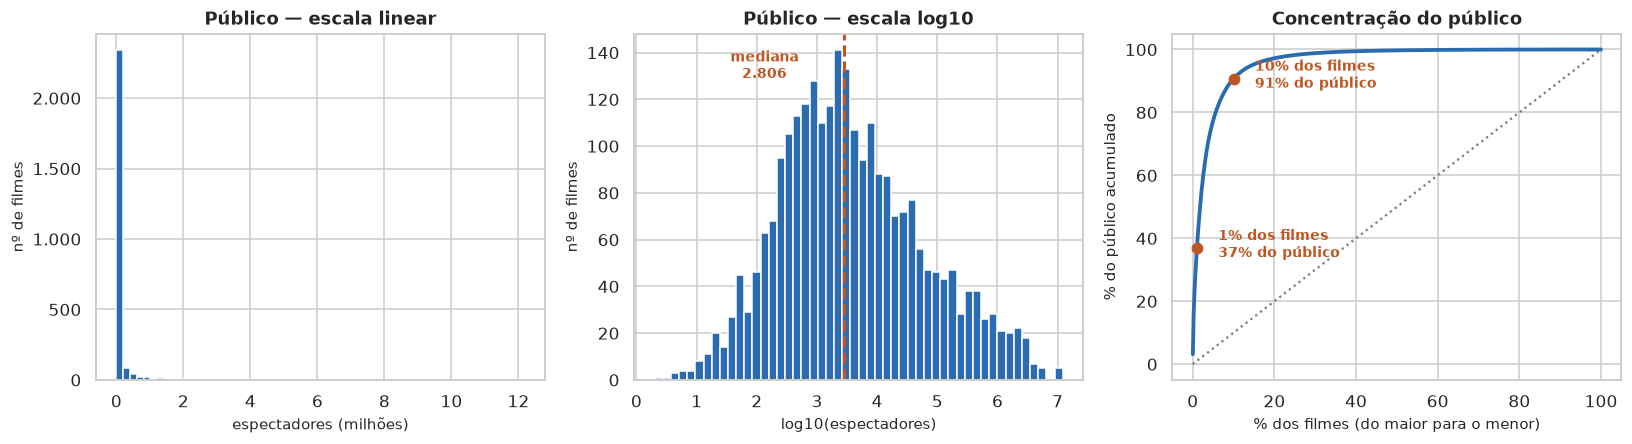

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

pub = d["publico"].dropna()

axes[0].hist(pub, bins=60, color=COR)
axes[0].set_title("Público — escala linear")
axes[0].set_xlabel("espectadores (milhões)"); axes[0].set_ylabel("nº de filmes")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}"))
milhares(axes[0], "y")

axes[1].hist(np.log10(pub), bins=50, color=COR)
axes[1].set_title("Público — escala log10")
axes[1].set_xlabel("log10(espectadores)"); axes[1].set_ylabel("nº de filmes")
mediana_pub = pub.median()
axes[1].axvline(np.log10(mediana_pub), color=COR2, ls="--", lw=2)
axes[1].annotate("mediana\n{:,.0f}".format(mediana_pub).replace(",", "."),
                 xy=(np.log10(mediana_pub), axes[1].get_ylim()[1]),
                 xytext=(-52, -10), textcoords="offset points",
                 color=COR2, ha="center", va="top", fontsize=9, fontweight="bold")

# curva de concentracao
ordenado = pub.sort_values(ascending=False).to_numpy()
acum = np.cumsum(ordenado) / ordenado.sum() * 100
frac = np.arange(1, len(ordenado) + 1) / len(ordenado) * 100
axes[2].plot(frac, acum, color=COR, lw=2.5)
axes[2].plot([0, 100], [0, 100], color="grey", ls=":", lw=1.5)
axes[2].set_title("Concentração do público")
axes[2].set_xlabel("% dos filmes (do maior para o menor)")
axes[2].set_ylabel("% do público acumulado")
for x in (1, 10):
    y = acum[int(len(acum) * x / 100)]
    axes[2].scatter([x], [y], color=COR2, zorder=5, s=45)
    axes[2].annotate(f"{x}% dos filmes\n{y:.0f}% do público",
                     (x, y), textcoords="offset points", xytext=(14, -6),
                     fontsize=9, color=COR2, fontweight="bold")

salvar(fig, "fig01-distribuicao-publico"); plt.show()

**O que a figura revela.** O painel da esquerda é quase uma barra única colada no zero:
na escala linear, a variação que importa para 99% dos filmes é invisível. O painel do
meio, em log10, revela o que estava escondido — a distribuição é aproximadamente
log-normal, espalhada por **sete ordens de grandeza**, de 2 espectadores a 12 milhões.

O painel da direita quantifica a concentração: **1% dos filmes concentra 36% de todo o
público; 10% concentram 91%.** A metade inferior da base inteira responde por 0,28%.

**Implicação para a modelagem.** A transformação logarítmica não é cosmética aqui, é
condição para que qualquer método baseado em distância ou em coeficiente linear
enxergue estrutura. Fica a hipótese **H3**, medida em S5. Note também que a curva de
concentração é o argumento contra tratar a cauda como *outlier* a remover: aqueles
pontos não são erro de medição, são o fenômeno.

## 2.3 Evolução do mercado ao longo do tempo

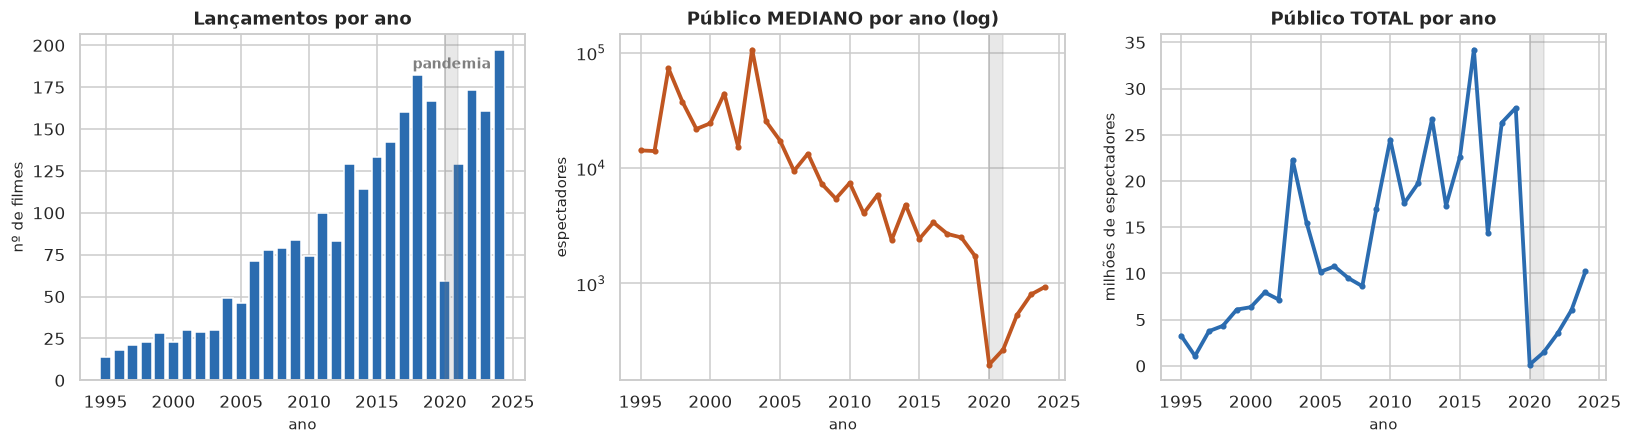

In [10]:
por_ano = d.groupby("ano").agg(
    lancamentos=("titulo", "size"),
    publico_mediano=("publico", "median"),
    publico_total=("publico", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].bar(por_ano.ano, por_ano.lancamentos, color=COR)
axes[0].set_title("Lançamentos por ano"); axes[0].set_ylabel("nº de filmes")

axes[1].plot(por_ano.ano, por_ano.publico_mediano, color=COR2, lw=2.5, marker="o", ms=3)
axes[1].set_yscale("log")
axes[1].set_title("Público MEDIANO por ano (log)"); axes[1].set_ylabel("espectadores")

axes[2].plot(por_ano.ano, por_ano.publico_total / 1e6, color=COR, lw=2.5, marker="o", ms=3)
axes[2].set_title("Público TOTAL por ano"); axes[2].set_ylabel("milhões de espectadores")

for ax in axes:
    ax.set_xlabel("ano")
    ax.axvspan(2020, 2021, color="grey", alpha=.18)
axes[0].annotate("pandemia", (2020.5, axes[0].get_ylim()[1] * .9),
                 ha="center", fontsize=9, color="grey", fontweight="bold")

salvar(fig, "fig02-evolucao-anual"); plt.show()

**O que a figura revela.** Três movimentos que precisam ser lidos juntos.

O número de lançamentos **explode**: de 14 filmes em 1995 para mais de 180 por ano na
década de 2010. O público *total*, porém, não acompanha na mesma proporção — e o
público **mediano** por filme **despenca**, de dezenas de milhares nos anos 1990 para
poucos milhares nos anos 2020, numa queda de mais de uma ordem de grandeza.

Não é que o cinema brasileiro tenha encolhido. É que o conjunto de filmes que chegam
à sala mudou de natureza: entrou uma quantidade enorme de documentários e produções de
circuito limitado que antes não eram lançados comercialmente. A queda da mediana é um
efeito de composição.

A faixa cinza marca 2020–2021. A pandemia aparece como um choque real na série, não
como ruído.

**Implicação para a modelagem — e esta é a mais séria do trabalho.** Se o público
mediano de 1995 é uma ordem de grandeza maior que o de 2024, então um corte pela
mediana **global** classifica quase todo filme antigo como sucesso e quase todo filme
recente como fracasso. O alvo passaria a codificar o ano. A seção 4.3 mede isso.

## 2.4 Distribuição dos atributos categóricos

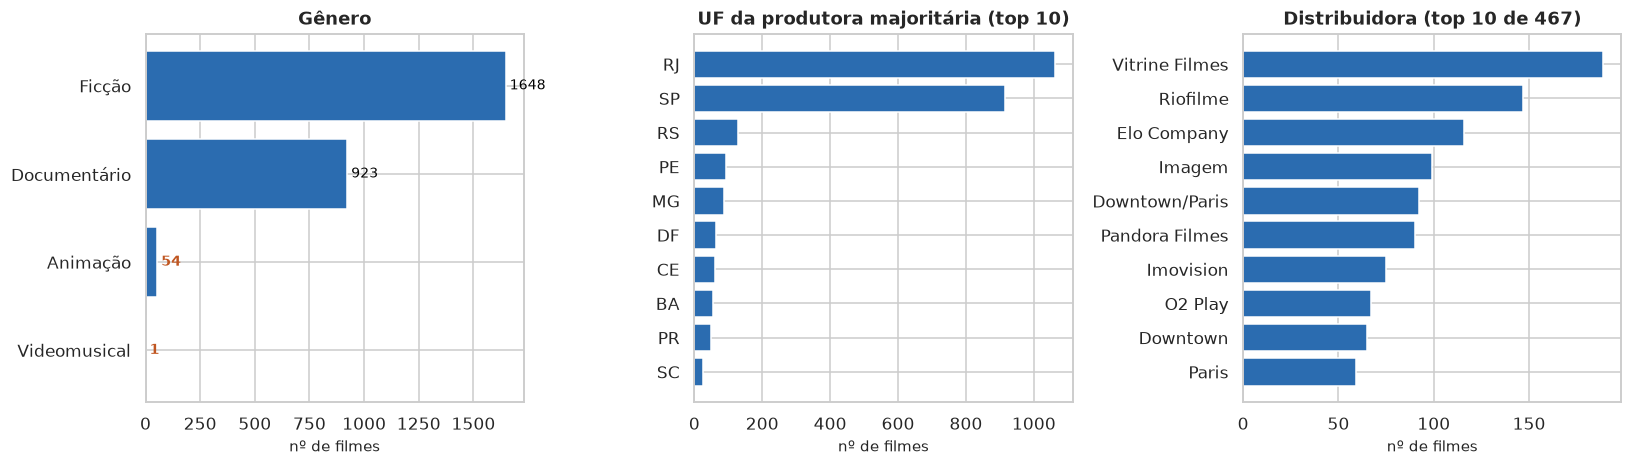

Concentração por categoria
  genero               4 distintos | top-1 =  62.8% | top-5 = 100.0% | com 1 só filme: 1
  uf_maj              24 distintos | top-1 =  40.5% | top-5 =  87.2% | com 1 só filme: 3
  distribuidora      467 distintos | top-1 =   7.2% | top-5 =  24.5% | com 1 só filme: 287
  direcao           1738 distintos | top-1 =   0.5% | top-5 =   2.1% | com 1 só filme: 1321
  produtora_maj     1502 distintos | top-1 =   1.3% | top-5 =   4.9% | com 1 só filme: 1090


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

g = d.genero.value_counts()
axes[0].barh(g.index[::-1], g.values[::-1], color=COR)
axes[0].set_title("Gênero")
for i, v in enumerate(g.values[::-1]):
    axes[0].text(v + 18, i, f"{v}", va="center", fontsize=9,
                 color=COR2 if v < 60 else "black",
                 fontweight="bold" if v < 60 else "normal")

u = d.uf_maj.value_counts().head(10)
axes[1].barh(u.index[::-1], u.values[::-1], color=COR)
axes[1].set_title("UF da produtora majoritária (top 10)")

dist = d.distribuidora.value_counts()
axes[2].barh(dist.index[:10][::-1], dist.values[:10][::-1], color=COR)
axes[2].set_title(f"Distribuidora (top 10 de {d.distribuidora.nunique()})")

for ax in axes:
    ax.set_xlabel("nº de filmes")
salvar(fig, "fig03-categoricas"); plt.show()

print("Concentração por categoria")
for c in ["genero", "uf_maj", "distribuidora", "direcao", "produtora_maj"]:
    vc = d[c].value_counts(normalize=True)
    n1 = int((d[c].value_counts() == 1).sum())
    print(f"  {c:<16} {d[c].nunique():>5} distintos | "
          f"top-1 = {vc.iloc[0]*100:>5.1f}% | "
          f"top-5 = {vc.head(5).sum()*100:>5.1f}% | "
          f"com 1 só filme: {n1}")

**O que a figura revela.** Cardinalidade e concentração são problemas opostos aqui,
e ambos aparecem.

`genero` tem apenas **4 categorias**, e uma delas — *Videomusical* — tem **um único
filme**. Numa validação cruzada de 5 folds, essa categoria estará ausente do treino em
pelo menos 4 dos folds. Não é uma categoria: é um registro.

UF majoritária mostra a concentração geográfica da produção: RJ e SP concentram a grande
maioria dos filmes. É um retrato conhecido do setor, e significa que as demais UFs terão
poucas dezenas de casos cada.

`distribuidora` é o oposto: **467 categorias**. Um *one-hot* ingênuo criaria 467 colunas
numa base de 2.626 linhas — mais dimensão do que informação. Pior: várias distribuidoras
aparecem em **um único filme**, e essas colunas seriam indicadores individuais, ou seja,
memorização disfarçada de atributo.

Há ainda um problema de **entidade fragmentada** que a contagem não captura: a base
traz `Downtown` (65 filmes), `Paris` (59) e `Downtown/Paris` (92) como três categorias
distintas, embora se refiram às mesmas empresas em arranjos diferentes.

**Implicação.** Hipótese **H4**: agrupar categorias raras num balde. O ponto de corte não
é óbvio, e é medido em S4.

## 2.5 Fomento público: o dinheiro chega a filmes que encontram plateia?

Esta é a seção que liga o trabalho à sua justificativa. A ANCINE publica quais obras
tiveram investimento do **FSA** (Fundo Setorial do Audiovisual) e quais tiveram projeto
aprovado nas **leis de incentivo**. As duas junções são por CPB e cobrem **67,1%** dos
filmes com CPB válido.

O que torna esses atributos utilizáveis: **fomento é aprovado antes de a obra existir**.
Diferente da renda ou do número de salas, não há como ele carregar o desempenho — é
informação genuinamente anterior à estreia.

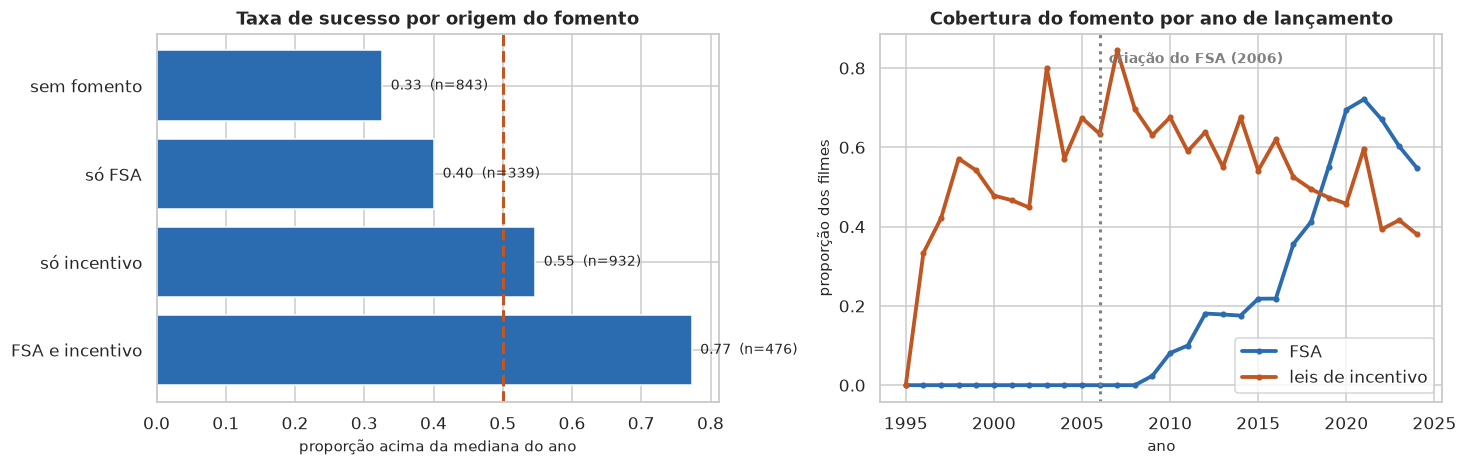

,filmes,taxa_sucesso,publico_mediano
origem_do_fomento,,,
sem fomento,843,0.326,1495.0
só FSA,339,0.401,535.0
só incentivo,932,0.547,7471.5
FSA e incentivo,476,0.773,7562.0


In [12]:
ordem_fom = ["sem fomento", "só FSA", "só incentivo", "FSA e incentivo"]
fom = (d.dropna(subset=["origem_do_fomento", "publico"])
         .groupby("origem_do_fomento")
         .agg(filmes=("titulo", "size"),
              taxa_sucesso=("sucesso_no_ano", "mean"),
              publico_mediano=("publico", "median"))
         .reindex(ordem_fom))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

axes[0].barh(fom.index[::-1], fom.taxa_sucesso.values[::-1], color=COR)
axes[0].axvline(.5, color=COR2, ls="--", lw=2)
axes[0].set_title("Taxa de sucesso por origem do fomento")
axes[0].set_xlabel("proporção acima da mediana do ano")
for i, (v, n) in enumerate(zip(fom.taxa_sucesso.values[::-1], fom.filmes.values[::-1])):
    axes[0].text(v + .012, i, f"{v:.2f}  (n={int(n)})", va="center", fontsize=9)

# cobertura por ano, o fsa so existe a partir de 2006
cob = d.groupby("ano")[["recebeu_fsa", "recebeu_incentivo"]].mean()
axes[1].plot(cob.index, cob.recebeu_fsa, lw=2.5, color=COR, marker="o", ms=3, label="FSA")
axes[1].plot(cob.index, cob.recebeu_incentivo, lw=2.5, color=COR2, marker="o", ms=3,
             label="leis de incentivo")
axes[1].axvline(2006, color="grey", ls=":", lw=2)
axes[1].annotate("criação do FSA (2006)", xy=(2006, axes[1].get_ylim()[1]),
                 xytext=(6, -12), textcoords="offset points", fontsize=9,
                 color="grey", fontweight="bold", va="top")
axes[1].set_title("Cobertura do fomento por ano de lançamento")
axes[1].set_xlabel("ano"); axes[1].set_ylabel("proporção dos filmes")
axes[1].legend(frameon=True, loc="lower right")

salvar(fig, "fig09-fomento"); plt.show()
fom.round(3)

**O que a figura revela — e há uma inversão que merece atenção.**

O gradiente é forte e ordenado: filmes **sem fomento** ficam acima da mediana do ano em
**32,6%** dos casos; com **só incentivo**, 54,7%; com **FSA e incentivo juntos**,
**77,3%**. A combinação dos dois mecanismos mais que dobra a taxa em relação a não ter
nenhum.

A inversão está no grupo **só FSA**: taxa de sucesso de 40,1%, mas **público mediano de
apenas 535 espectadores** — abaixo dos 1.495 do grupo *sem fomento*. Um mecanismo que
seleciona filmes que ficam acima da mediana do seu ano, mas cuja mediana absoluta é
baixa, é um mecanismo que financia **muito documentário e produção de circuito
limitado**. Não é crítica ao FSA: é descrição do que ele financia.

**⚠️ O confundimento que precisa ser dito.** O FSA foi criado em **2006**. Nenhum filme
dos anos 1990 poderia tê-lo, e de fato a cobertura é 0,0% naquela década contra 63,3%
nos anos 2020. recebeu FSA tem **ρ = 0,511 com `ano`** — é, em parte, um marcador de
"filme recente".

Isso **não** o invalida, e a verificação que mostra por quê é direta: dentro dos anos
2010 **isoladamente**, o gradiente se mantém — 80,4% de sucesso para *FSA e incentivo*
contra 28,7% para *sem fomento*. O efeito sobrevive ao controle temporal.

**Implicação para a modelagem.** recebeu incentivo (ρ = −0,146 com o ano) entra sem
ressalva. recebeu FSA exige que `ano` esteja no modelo, ou que a comparação seja feita
dentro do ano — que é exatamente o que o alvo sucesso no ano já faz. Fica a hipótese
**H14**.

## 2.6 Público por gênero

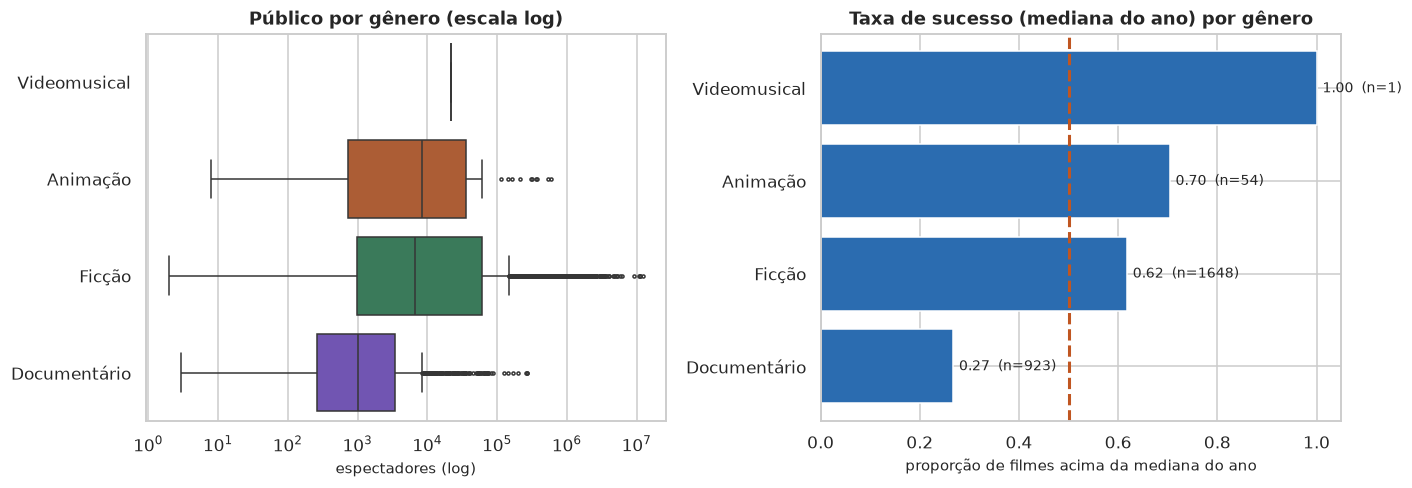

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ordem = d.groupby("genero")["publico"].median().sort_values(ascending=False).index
sns.boxplot(data=d, x="publico", y="genero", order=ordem, ax=axes[0],
            palette=PALETA, showfliers=True, fliersize=2)
axes[0].set_xscale("log")
axes[0].set_title("Público por gênero (escala log)")
axes[0].set_xlabel("espectadores (log)"); axes[0].set_ylabel("")

taxa = d.groupby("genero")["sucesso_no_ano"].agg(["mean", "size"]).reindex(ordem)
b = axes[1].barh(taxa.index[::-1], taxa["mean"].values[::-1], color=COR)
axes[1].axvline(.5, color=COR2, ls="--", lw=2)
axes[1].set_title("Taxa de sucesso (mediana do ano) por gênero")
axes[1].set_xlabel("proporção de filmes acima da mediana do ano")
for i, (v, n) in enumerate(zip(taxa["mean"].values[::-1], taxa["size"].values[::-1])):
    axes[1].text(v + .012, i, f"{v:.2f}  (n={n})", va="center", fontsize=9)

salvar(fig, "fig04-publico-por-genero"); plt.show()

**O que a figura revela.** A separação por gênero é real e forte. A mediana de público
da Animação e da Ficção está uma a duas ordens de grandeza acima da do Documentário —
e a taxa de sucesso confirma: cerca de dois terços das ficções ficam acima da mediana
do ano, contra menos de um terço dos documentários.

As caixas, porém, **se sobrepõem amplamente**. Existem documentários com centenas de
milhares de espectadores e ficções com dezenas. Gênero informa, mas está longe de
determinar.

*Videomusical* aparece como um traço sem caixa: com n=1, não há quartil a desenhar.
A figura torna visível o problema apontado na seção 2.4.

**Implicação.** `genero` é um atributo informativo e de baixa cardinalidade — candidato
natural a *one-hot* sem agrupamento. O único cuidado é a categoria de um registro só.

## 2.7 Correlação entre as variáveis numéricas

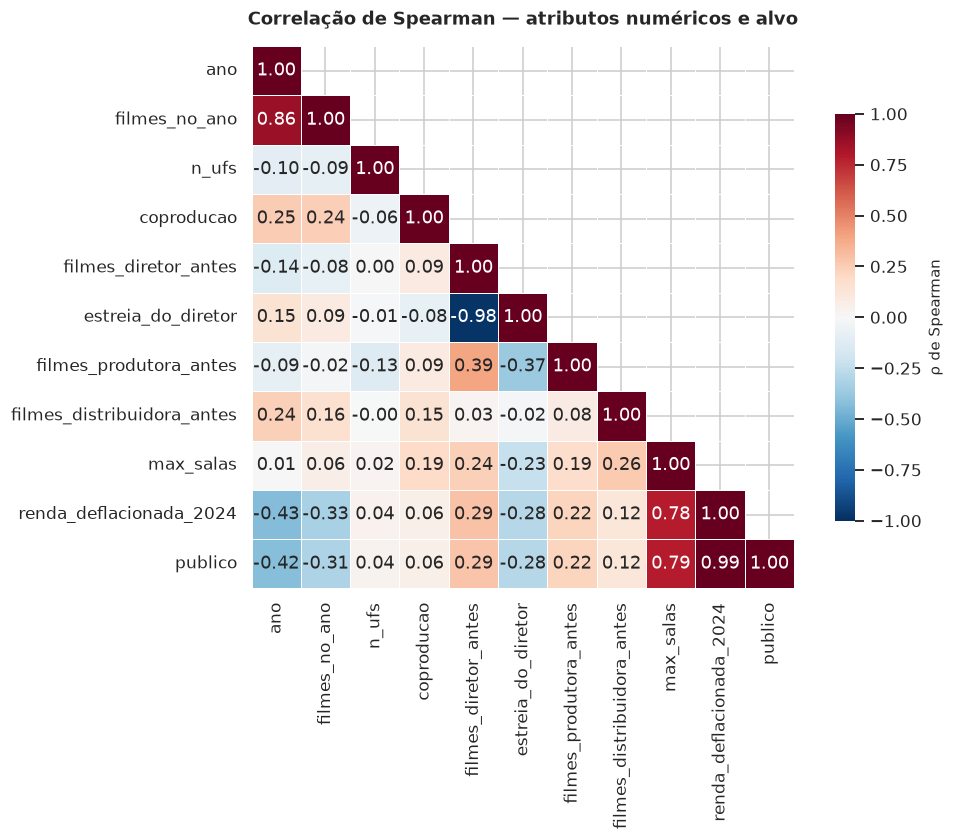

In [14]:
COR_MAPA = ["ano", "filmes_no_ano", "n_ufs", "coproducao",
            "filmes_diretor_antes", "estreia_do_diretor",
            "filmes_produtora_antes", "filmes_distribuidora_antes",
            "max_salas", "renda_deflacionada_2024", "publico"]

corr = d[COR_MAPA].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 7.8))
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .75, "label": "ρ de Spearman"}, ax=ax)
ax.set_title("Correlação de Spearman — atributos numéricos e alvo", pad=14)
salvar(fig, "fig05-correlacao"); plt.show()

Usamos **Spearman**, não Pearson: com assimetria acima de 10, Pearson mediria o efeito
dos poucos blockbusters, não a relação monotônica que nos interessa.

**O que a figura revela.** Três blocos, e cada um exige uma decisão diferente.

**Bloco 1 — correlação quase perfeita com o alvo.** renda deflacionada tem
ρ = 0,99 com `publico`. Não é descoberta: renda é público multiplicado pelo preço do
ingresso. É a mesma variável em outra unidade.

**Bloco 2 — correlação alta e suspeita.** máximo de salas tem ρ = 0,79 com `publico`. Este
é o caso interessante, e a seção 4.5 argumenta que ele é vazamento.

**Bloco 3 — redundância entre atributos.** `ano` e filmes lançados no ano têm ρ = 0,86: como a
figura 3.2 mostrou, o número de lançamentos cresce com o tempo, então uma variável
carrega a outra. E filmes anteriores da direção com estreia da direção chega a ρ = 0,98 —
redundância que **nós mesmos introduzimos**, já que a segunda é uma binarização da
primeira. Vale registrar em vez de esconder.

Fora esses blocos, as correlações com o público são modestas: histórico da direção
(0,29), da produtora (0,22), da distribuidora (0,12), coprodução (0,06). Nenhum atributo
"honesto" sozinho explica o sucesso — o que é esperado e é justamente o que dá sentido
a usar um modelo.

## 2.8 Relação de cada atributo com a variável-alvo

O heatmap acima mede atributo contra atributo, e contra `publico`. Falta a outra metade
do que o enunciado pede: a relação de cada atributo com a **variável-alvo** — que é
binária, e por isso exige duas medidas diferentes.

Para as numéricas, **ρ de Spearman** com sucesso no ano. Para as categóricas, Spearman
não serve: usamos o **V de Cramér**, que mede associação entre duas categóricas e varia
de 0 (independência) a 1 (determinação).

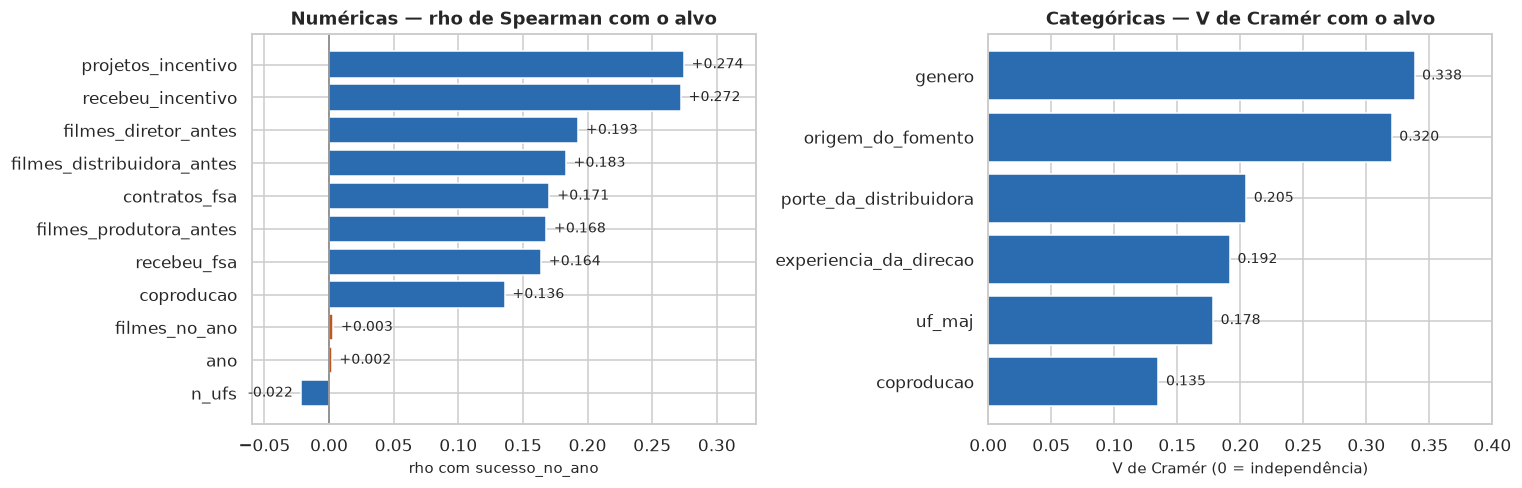

In [15]:
from scipy.stats import chi2_contingency, spearmanr

def cramer_v(x, y):
    # v de cramer: associacao entre duas categoricas, de 0 a 1
    tabela = pd.crosstab(x, y)
    qui = chi2_contingency(tabela)[0]
    n = tabela.values.sum()
    return np.sqrt((qui / n) / (min(tabela.shape) - 1))

alvo = "sucesso_no_ano"
b = d.dropna(subset=[alvo])

NUM_ALVO = ["projetos_incentivo", "recebeu_incentivo", "filmes_diretor_antes",
            "filmes_distribuidora_antes", "contratos_fsa", "filmes_produtora_antes",
            "recebeu_fsa", "coproducao", "n_ufs", "filmes_no_ano", "ano"]
CAT_ALVO = ["genero", "origem_do_fomento", "porte_da_distribuidora",
            "experiencia_da_direcao", "uf_maj", "coproducao"]

rho = pd.Series(
    {c: spearmanr(b[c].fillna(b[c].median()), b[alvo]).statistic for c in NUM_ALVO}
).sort_values()
vcr = pd.Series(
    {c: cramer_v(b.dropna(subset=[c])[c], b.dropna(subset=[c])[alvo]) for c in CAT_ALVO}
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

cores = [COR2 if abs(v) < 0.02 else COR for v in rho.values]
axes[0].barh(rho.index, rho.values, color=cores)
axes[0].axvline(0, color="grey", lw=1)
axes[0].set_title("Numéricas — rho de Spearman com o alvo")
axes[0].set_xlabel("rho com sucesso_no_ano")
for i, v in enumerate(rho.values):
    axes[0].text(v + (.006 if v >= 0 else -.006), i, f"{v:+.3f}",
                 va="center", ha="left" if v >= 0 else "right", fontsize=9)
axes[0].set_xlim(-0.06, 0.33)

axes[1].barh(vcr.index, vcr.values, color=COR)
axes[1].set_title("Categóricas — V de Cramér com o alvo")
axes[1].set_xlabel("V de Cramér (0 = independência)")
for i, v in enumerate(vcr.values):
    axes[1].text(v + .006, i, f"{v:.3f}", va="center", fontsize=9)
axes[1].set_xlim(0, 0.40)

salvar(fig, "fig10-correlacao-com-alvo"); plt.show()

**O que a figura revela — e ela fecha o argumento central do trabalho.**

Olhem as duas barras laranja no painel da esquerda: **`ano` tem rho = +0,002 com o alvo,
e filmes lançados no ano tem +0,003.** Praticamente zero.

Isso é a confirmação empírica de tudo o que a seção 3.3 vai mostrar. Com
sucesso global, o ano seria um dos atributos mais preditivos da base, porque a mediana
global embute o calendário. Ao definir o alvo **relativo à mediana do próprio ano**, a
informação temporal foi **completamente neutralizada** — o modelo não tem mais como usar
o relógio como atalho. Não é argumento: é número.

**O que sobra quando o atalho sai.** O atributo honesto mais associado ao alvo é
projetos de incentivo (**+0,274**), seguido do histórico da direção (+0,193) e da
distribuidora (+0,183). São correlações **modestas** — nenhuma chega a 0,3 — e isso é
esperado: se um atributo isolado explicasse o sucesso de um filme, não haveria indústria
de cinema.

**E as categóricas mudam o ranking.** Pelo V de Cramér, **`genero` (0,338) é o atributo
mais associado ao alvo em toda a base** — acima de qualquer numérica. origem do fomento
vem logo atrás (0,320). Isso não aparece no heatmap de Spearman, porque Spearman não
opera sobre categórica nominal.

**Implicação para a modelagem.** A codificação das categóricas importa mais que a
transformação das numéricas nesta base — é onde está o sinal. Reforça **H4** (agrupar
categorias raras) e explica por que **H13** descarta PCA: o gargalo de dimensionalidade
é categórico, não numérico.

## 2.9 Os atributos ordinais e a dimensão regional

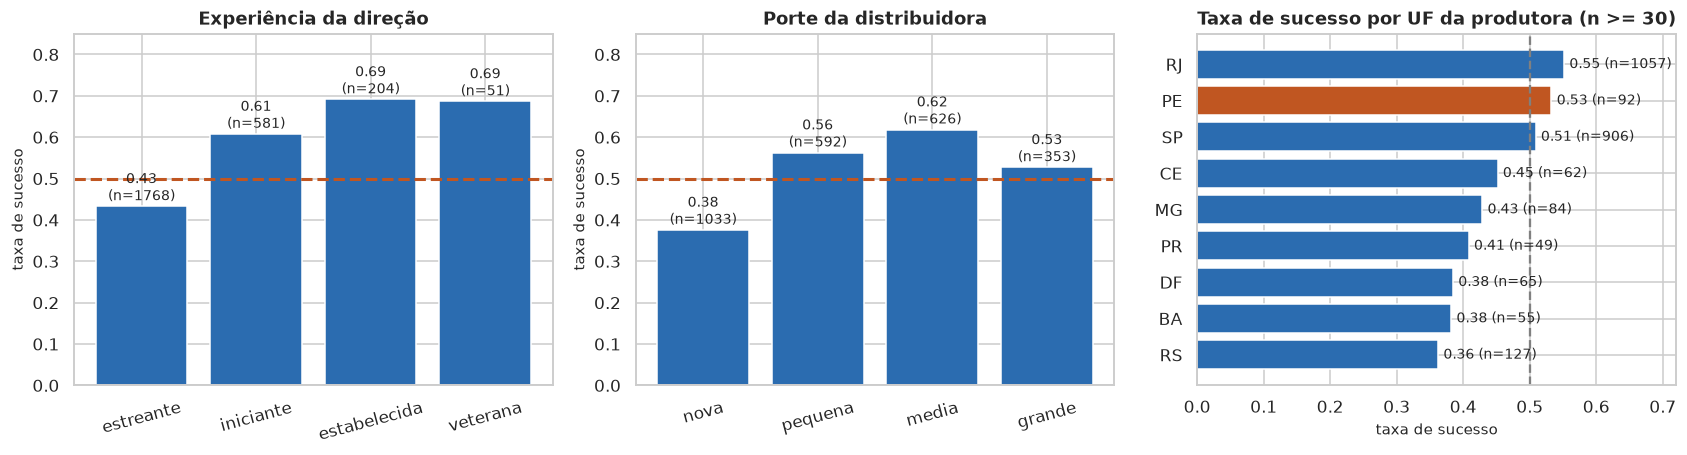

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

# as duas ordinais, na ordem delas
for eixo, col, titulo in [
        (axes[0], "experiencia_da_direcao", "Experiência da direção"),
        (axes[1], "porte_da_distribuidora", "Porte da distribuidora")]:
    g = (b.groupby(col, observed=True)
           .agg(taxa=(alvo, "mean"), n=("titulo", "size")))
    eixo.bar(range(len(g)), g.taxa, color=COR)
    eixo.axhline(.5, color=COR2, ls="--", lw=2)
    eixo.set_xticks(range(len(g)))
    eixo.set_xticklabels(g.index, rotation=15)
    eixo.set_title(titulo)
    eixo.set_ylabel("taxa de sucesso")
    eixo.set_ylim(0, .85)
    for i, (t, n) in enumerate(zip(g.taxa, g.n)):
        eixo.text(i, t + .015, f"{t:.2f}\n(n={n})", ha="center", fontsize=9)

# so uf com pelo menos 30 filmes
u = (b.groupby("uf_maj").agg(taxa=(alvo, "mean"), n=("titulo", "size"))
       .query("n >= 30").sort_values("taxa"))
cores_uf = [COR2 if uf == "PE" else COR for uf in u.index]
axes[2].barh(u.index, u.taxa, color=cores_uf)
axes[2].axvline(.5, color="grey", ls="--", lw=1.5)
axes[2].set_title("Taxa de sucesso por UF da produtora (n >= 30)")
axes[2].set_xlabel("taxa de sucesso")
for i, (t, n) in enumerate(zip(u.taxa, u.n)):
    axes[2].text(t + .008, i, f"{t:.2f} (n={n})", va="center", fontsize=9)
axes[2].set_xlim(0, .72)

salvar(fig, "fig11-ordinais-e-regiao"); plt.show()

**O que a figura revela.**

**A experiência da direção tem gradiente e satura.** De 0,43 para estreantes a 0,69 para
direções estabelecidas — e a faixa *veterana* fica em 0,69, igual. A curva sobe e achata:
os primeiros filmes de carreira são os que mais mudam a chance, e depois o retorno
marginal desaparece. É comportamento típico de variável de reputação, e justifica ter
binado a contagem em faixas em vez de usá-la crua.

**O porte da distribuidora NÃO é monótono, e isso é achado.** Sobe de 0,38 (nova) para
0,62 (média) e **cai para 0,53 na faixa grande**. A leitura é que o atributo mede
**volume de catálogo, não poder comercial**: a distribuidora com mais filmes na base é a
Vitrine Filmes, com 189 — e boa parte do que ela distribui é circuito de arte. Uma
ordinal cuja ordem não se traduz em gradiente monótono continua informativa, mas avisa
que o rótulo "grande" não significa o que o senso comum sugere.

**A dimensão regional.** Entre as UFs com pelo menos 30 filmes, a taxa vai de **0,36 no
Rio Grande do Sul a 0,55 no Rio de Janeiro** — 19 pontos de amplitude. O destaque em
laranja: **Pernambuco aparece em segundo, com 0,53 e 92 filmes**, à frente de São Paulo.
Não é ruído de amostra pequena, e é consistente com o que se sabe do setor sobre a
produção pernambucana.

⚠️ **Associação, não causalidade.** UF aqui é o endereço fiscal da produtora
majoritária — não onde o filme foi rodado nem onde foi visto. E está confundida com
gênero e com acesso a fomento: separar os efeitos é modelagem, não EDA.

## 2.10 Relação entre salas e público

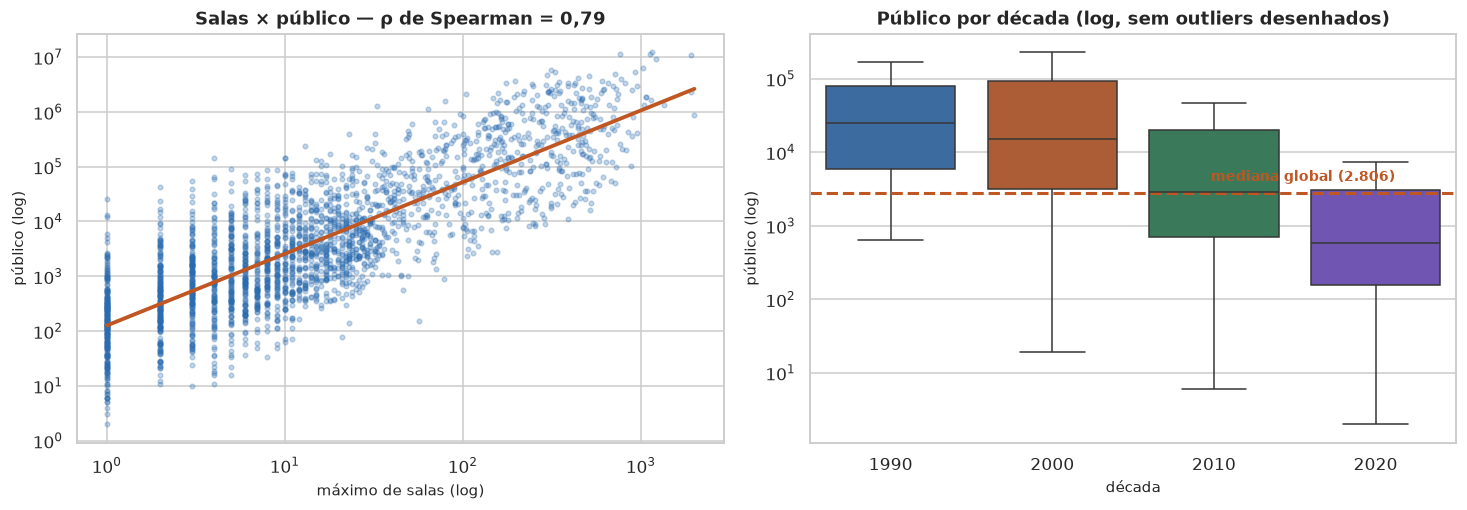

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

amostra = d.dropna(subset=["max_salas", "publico"])
axes[0].scatter(amostra.max_salas, amostra.publico, s=9, alpha=.28, color=COR)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("máximo de salas (log)"); axes[0].set_ylabel("público (log)")
axes[0].set_title("Salas × público — ρ de Spearman = 0,79")
z = np.polyfit(np.log10(amostra.max_salas), np.log10(amostra.publico), 1)
xs = np.linspace(np.log10(amostra.max_salas.min()), np.log10(amostra.max_salas.max()), 50)
axes[0].plot(10**xs, 10**np.polyval(z, xs), color=COR2, lw=2.5)

por_dec = d.dropna(subset=["publico"]).copy()
sns.boxplot(data=por_dec, x="decada", y="publico", ax=axes[1], palette=PALETA,
            showfliers=False)
axes[1].set_yscale("log")
axes[1].set_title("Público por década (log, sem outliers desenhados)")
axes[1].set_xlabel("década"); axes[1].set_ylabel("público (log)")
axes[1].axhline(d.publico.median(), color=COR2, ls="--", lw=2)
axes[1].annotate("mediana global (2.806)", (2.55, d.publico.median() * 1.45),
                 color=COR2, fontsize=9, fontweight="bold", ha="center")

salvar(fig, "fig06-salas-e-decada"); plt.show()

**O que a figura revela.** À esquerda, a relação entre salas e público é quase uma reta
em escala log-log — um filme em 1.000 salas faz sistematicamente mais público que um em
5 salas. À direita está o problema.

O painel da direita é a evidência visual do que a seção 3.3 vai medir: a linha tracejada
é a mediana **global**, e ela corta as quatro décadas em alturas completamente
diferentes. Nos anos 1990 a caixa inteira está acima da linha; nos anos 2020, quase toda
a caixa está abaixo. Um classificador que receba `ano` como atributo e sucesso global
como alvo não precisa aprender nada sobre cinema.

---

# 3. Diagnóstico dos dados

## 3.1 Valores ausentes

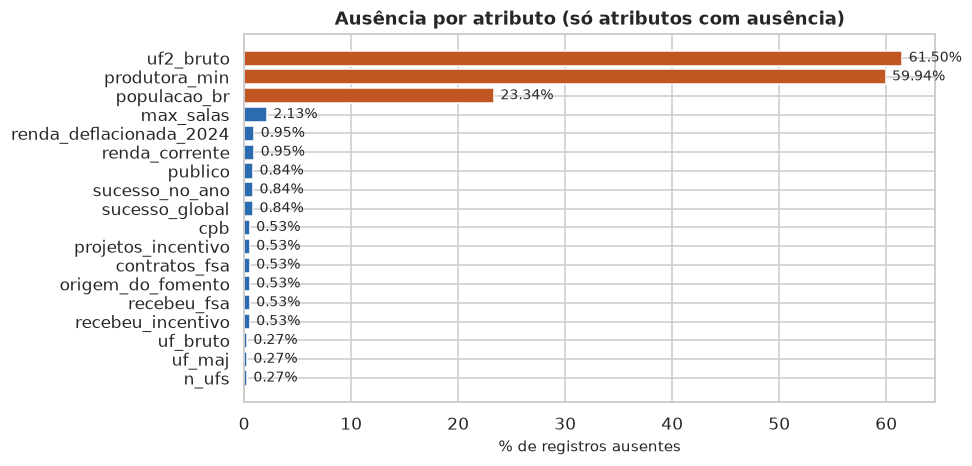

Padrão de ausência — o que cada caso significa
  produtora_min / uf2_bruto (59.9%): NÃO é falta. É ausência estrutural: o filme não teve coprodutora.
  populacao_br (23.3%): falta de JUNÇÃO. O IBGE não publica estimativa para 1995-2000.
  max_salas (2.13%): 'ND' no arquivo da ANCINE.
  publico (0.84%): 'ND' — e sem público não há alvo.

Ausência de max_salas é aleatória? Média de público por grupo:
                   size  median      mean
max_salas                                
tem max_salas      2570  2753.0  150269.0
max_salas ausente    56  3400.0   18631.0


In [18]:
aus = (d.isna().mean() * 100).sort_values(ascending=False)
aus = aus[aus > 0]

fig, ax = plt.subplots(figsize=(9, 4.4))
cores = [COR2 if v > 20 else COR for v in aus.values]
ax.barh(aus.index[::-1], aus.values[::-1], color=cores[::-1])
ax.set_xlabel("% de registros ausentes")
ax.set_title("Ausência por atributo (só atributos com ausência)")
for i, v in enumerate(aus.values[::-1]):
    ax.text(v + .6, i, f"{v:.2f}%", va="center", fontsize=9)
salvar(fig, "fig07-ausentes"); plt.show()

print("Padrão de ausência — o que cada caso significa")
print(f"  produtora_min / uf2_bruto ({aus.get('produtora_min',0):.1f}%): "
      "NÃO é falta. É ausência estrutural: o filme não teve coprodutora.")
print(f"  populacao_br ({aus.get('populacao_br',0):.1f}%): falta de JUNÇÃO. "
      "O IBGE não publica estimativa para 1995-2000.")
print(f"  max_salas ({aus.get('max_salas',0):.2f}%): 'ND' no arquivo da ANCINE.")
print(f"  publico ({aus.get('publico',0):.2f}%): 'ND' — e sem público não há alvo.")
print()
print("Ausência de max_salas é aleatória? Média de público por grupo:")
print(d.groupby(d.max_salas.isna())["publico"].agg(["size", "median", "mean"]).rename(
    index={False: "tem max_salas", True: "max_salas ausente"}).round(0).to_string())

**O que o diagnóstico revela.** Os quatro casos de ausência têm **naturezas diferentes**,
e tratá-los com a mesma imputação seria um erro.

produtora minoritária e UF da minoritária como publicada (60% e 61%) **não são dados faltantes**. O arquivo traz
`-` porque o filme não teve produtora minoritária. Imputar aqui inventaria coprodução
onde não houve. Foi exatamente por isso que criamos `coproducao` como binária: a
informação está na própria ausência.

população do Brasil (23%) é falta de **junção**: o IBGE não publica estimativa populacional
para 1995–2000. É previsível, é sistemática e afeta apenas anos antigos — o que
significa que qualquer imputação teria de ser por interpolação temporal, não por média.

máximo de salas (2,1%) e `publico` (0,8%) são `ND` no arquivo original. E a ausência **não é
aleatória**: os filmes sem máximo de salas têm público mediano muito menor. É MNAR — a
própria ausência informa que o filme teve carreira mínima. Imputar pela mediana global
apagaria esse sinal.

Os 22 filmes sem `publico` **não têm alvo**. Não podem ser imputados: seriam rótulos
inventados. Serão descartados na Entrega 2, com registro do descarte.

## 3.2 Outliers, valores fora de domínio e registros duplicados

In [19]:
def iqr(s):
    q1, q3 = s.quantile([.25, .75]); ai = q3 - q1
    return ((s < q1 - 1.5 * ai) | (s > q3 + 1.5 * ai)).sum()

print("Outliers pelo critério IQR (1,5 × amplitude interquartil)")
for c in ["publico", "renda_deflacionada_2024", "max_salas",
          "filmes_diretor_antes", "filmes_produtora_antes"]:
    s = d[c].dropna()
    n = iqr(s)
    print(f"  {c:<28} {n:>5} de {len(s)}  ({n/len(s)*100:>5.1f}%)")

print("\nConsistência de domínio")
preco = d.renda_corrente / d.publico
print(f"  preço médio implícito do ingresso: mediana R$ {preco.median():.2f}, "
      f"faixa R$ {preco.min():.2f} – R$ {preco.max():.2f}")
print(f"  registros com preço implícito < R$ 1,00 (impossível): {(preco < 1).sum()}")
print(f"  filmes com público < 10 espectadores: {(d.publico < 10).sum()}  "
      f"(mínimo observado: {int(d.publico.min())})")
print(f"  renda > 0 mas público ausente: {((d.renda_corrente > 0) & d.publico.isna()).sum()}")
print(f"  público > 0 mas max_salas ausente: {((d.publico > 0) & d.max_salas.isna()).sum()}")
print(f"  valores negativos em qualquer numérica: "
      f"{int((d[NUM] < 0).sum().sum())}")

print("\nRegistros duplicados")
print(f"  linhas idênticas:              {d.duplicated().sum()}")
print(f"  mesmo título + mesmo ano:      {d.duplicated(['titulo','ano']).sum()}")
print(f"  mesmo CPB (chave da ANCINE):   {d[d.cpb.notna()].duplicated(['cpb']).sum()}")
print(f"  mesmo título em anos distintos:{d.duplicated(['titulo']).sum()}  "
      "(refilmagens e homônimos — legítimos)")

Outliers pelo critério IQR (1,5 × amplitude interquartil)
  publico                        454 de 2604  ( 17.4%)
  renda_deflacionada_2024        457 de 2601  ( 17.6%)
  max_salas                      452 de 2570  ( 17.6%)
  filmes_diretor_antes           255 de 2626  (  9.7%)
  filmes_produtora_antes         235 de 2626  (  8.9%)

Consistência de domínio
  preço médio implícito do ingresso: mediana R$ 11.16, faixa R$ 1.39 – R$ 31.43
  registros com preço implícito < R$ 1,00 (impossível): 0
  filmes com público < 10 espectadores: 13  (mínimo observado: 2)
  renda > 0 mas público ausente: 1
  público > 0 mas max_salas ausente: 37
  valores negativos em qualquer numérica: 0

Registros duplicados
  linhas idênticas:              0
  mesmo título + mesmo ano:      0
  mesmo CPB (chave da ANCINE):   0
  mesmo título em anos distintos:6  (refilmagens e homônimos — legítimos)


**O que o diagnóstico revela — e a conclusão contraria o reflexo padrão.**

O critério IQR marca **17,4%** dos filmes como *outlier* de público. Isso não é sinal de erro
nos dados: é sinal de que **o IQR é o critério errado para esta distribuição**. Num
regime de lei de potência, a cauda não é anomalia, é o fenômeno. Remover os filmes
marcados eliminaria justamente os casos que o modelo precisa aprender a reconhecer.

A **verificação de domínio confirma que os dados são consistentes**: o preço médio
implícito do ingresso (renda ÷ público) tem mediana de R$ 11,16 e fica sempre numa faixa
plausível — nenhum registro abaixo de R$ 1,00, nenhum acima de R$ 32. Não há valor
negativo. Os 13 filmes com menos de 10 espectadores são extremos, mas coerentes com
lançamento de sala única em circuito restrito.

Há **duas inconsistências pontuais**: 1 filme com renda registrada e público ausente, e
37 filmes com público registrado e máximo de salas ausente. São poucos e serão anotados.

**Não há duplicata**: nenhuma linha idêntica, nenhum CPB repetido. Os 6 títulos
repetidos ocorrem em anos diferentes — refilmagens e homônimos, que são registros
legítimos e distintos.

## 3.3 Desbalanceamento da variável-alvo

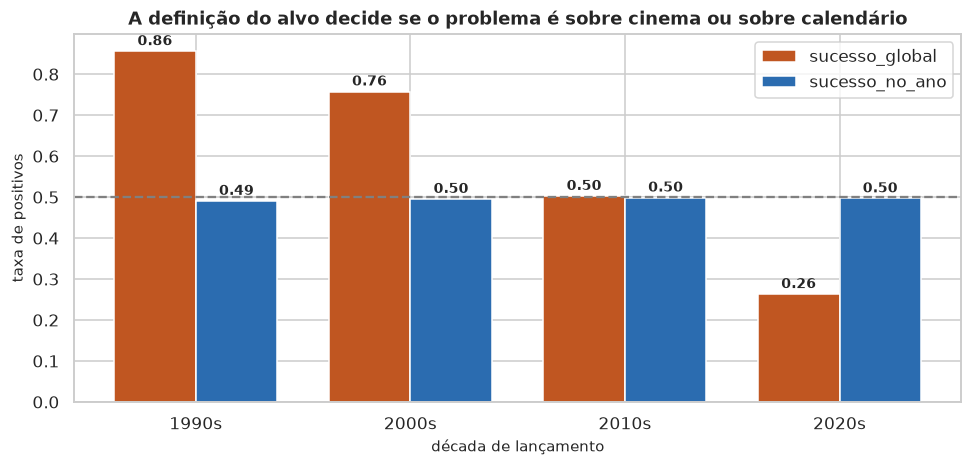

,sucesso_global,sucesso_no_ano
decada,,
1990,0.856,0.490
2000,0.757,0.495
2010,0.502,0.498
2020,0.263,0.497


In [20]:
por_dec = d.groupby("decada")[["sucesso_global", "sucesso_no_ano"]].mean()

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(por_dec)); larg = .38
ax.bar(x - larg/2, por_dec.sucesso_global, larg, label="sucesso_global", color=COR2)
ax.bar(x + larg/2, por_dec.sucesso_no_ano, larg, label="sucesso_no_ano", color=COR)
ax.axhline(.5, color="grey", ls="--", lw=1.5)
ax.set_xticks(x); ax.set_xticklabels([f"{int(i)}s" for i in por_dec.index])
ax.set_ylabel("taxa de positivos"); ax.set_xlabel("década de lançamento")
ax.set_title("A definição do alvo decide se o problema é sobre cinema ou sobre calendário")
ax.legend(frameon=True)
for i, (a, b) in enumerate(zip(por_dec.sucesso_global, por_dec.sucesso_no_ano)):
    ax.text(i - larg/2, a + .015, f"{a:.2f}", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + larg/2, b + .015, f"{b:.2f}", ha="center", fontsize=9, fontweight="bold")
salvar(fig, "fig08-alvo-por-decada"); plt.show()

por_dec.round(3)

**Este é o achado central do trabalho.**

Globalmente, os dois alvos são equilibrados: 50,0% e 49,7% de positivos. Se
parássemos aí, concluiríamos que não há problema de balanceamento e seguiríamos adiante.

Desagregado por década, o quadro se inverte. Com sucesso global, **85,6% dos filmes
dos anos 1990 são "sucesso" e apenas 26,3% dos anos 2020** — uma diferença de quase
60 pontos percentuais. O alvo não está medindo sucesso: está medindo **antiguidade**.
Um modelo que receba `ano` como atributo vai encontrar esse atalho, atingir um AUC alto
e não ter aprendido absolutamente nada sobre o que faz um filme dar certo.

Com sucesso no ano, as quatro décadas ficam coladas em 0,49–0,50 por construção. O
atalho desaparece e o modelo é obrigado a comparar cada filme com seus contemporâneos.

**O desbalanceamento desta base não está na proporção global de classes — está na
distribuição condicional do alvo ao longo do tempo.** É por isso que SMOTE não
resolveria nada aqui: o problema não é falta de exemplos de uma classe, é uma definição
de alvo que embute a variável errada.

## 3.4 Atributos redundantes, correlacionados ou de variância nula

## 2.9 O corte que os dados propõem — duas populações, não uma

A seção 2.1 mostrou que o público é **quase** log-normal. O "quase" importa. Se a
distribuição em log fosse uma única gaussiana, a mediana seria um centro legítimo e cortar
nela seria defensável. Vamos testar isso: ajustamos uma mistura de **duas** gaussianas em
`log10(publico)` e comparamos o BIC com o de uma só.

A pergunta é direta: **o corte deveria estar onde nós o colocamos, ou os dados indicam outro
lugar?**

In [21]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq
from matplotlib.ticker import FuncFormatter

pub = d["publico"].dropna()
X = np.log10(pub.to_numpy()).reshape(-1, 1)

# Uma gaussiana ou duas? O BIC decide, penalizando o modelo mais complexo.
for k in (1, 2, 3):
    print(f"mistura de {k} componente(s): BIC = {GaussianMixture(k, random_state=0).fit(X).bic(X):,.1f}")

g = GaussianMixture(2, random_state=0).fit(X)
ordem = np.argsort(g.means_.ravel())
peso, centro = g.weights_[ordem], g.means_.ravel()[ordem]
desvio = np.sqrt(g.covariances_.ravel())[ordem]

# Fronteira: o publico em que uma componente passa a dominar a outra.
densidade = lambda i, t: peso[i] * norm.pdf(t, centro[i], desvio[i])
fronteira = 10 ** brentq(lambda t: densidade(0, t) - densidade(1, t), centro[0], centro[1])

print(f"\ncircuito limitado ....... {peso[0]:.0%} dos filmes, centro em {10**centro[0]:,.0f} espectadores")
print(f"lancamento comercial .... {peso[1]:.0%} dos filmes, centro em {10**centro[1]:,.0f} espectadores")
print(f"\nfronteira entre as duas . {fronteira:,.0f} espectadores "
      f"= percentil {(pub < fronteira).mean():.1%}")
print(f"mediana (alvo atual) .... {pub.median():,.0f} espectadores = percentil 50,0%")

mistura de 1 componente(s): BIC = 8,358.3
mistura de 2 componente(s): BIC = 8,260.4
mistura de 3 componente(s): BIC = 8,279.4

circuito limitado ....... 64% dos filmes, centro em 915 espectadores
lancamento comercial .... 36% dos filmes, centro em 51,402 espectadores

fronteira entre as duas . 11,830 espectadores = percentil 68.7%
mediana (alvo atual) .... 2,806 espectadores = percentil 50,0%


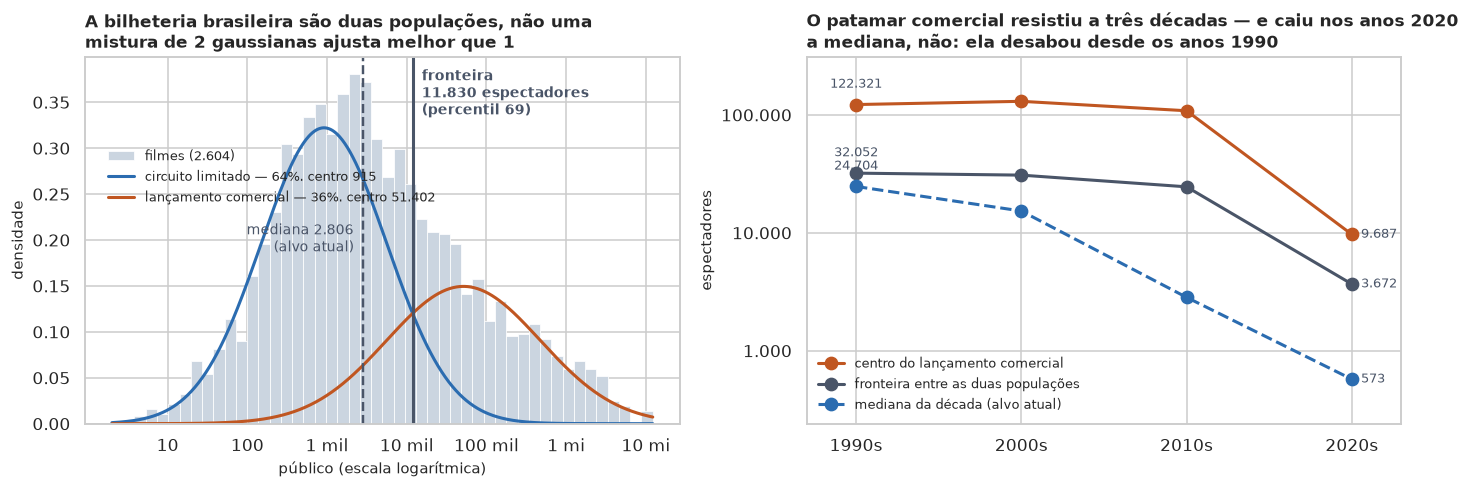

In [22]:
CURTO = {1: "10", 2: "100", 3: "1 mil", 4: "10 mil", 5: "100 mil", 6: "1 mi", 7: "10 mi"}

def mistura(v):
    """(pesos, centros, desvios, fronteira) de uma mistura de duas gaussianas em log10."""
    Xv = np.log10(v).reshape(-1, 1)
    gv = GaussianMixture(2, random_state=0).fit(Xv)
    o = np.argsort(gv.means_.ravel())
    w, m, s = gv.weights_[o], gv.means_.ravel()[o], np.sqrt(gv.covariances_.ravel())[o]
    f = lambda t: w[0] * norm.pdf(t, m[0], s[0]) - w[1] * norm.pdf(t, m[1], s[1])
    return w, m, s, 10 ** brentq(f, m[0], m[1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.hist(np.log10(pub), bins=48, density=True, color="#cbd5e0", edgecolor="white",
        linewidth=.5, label=f"filmes ({len(pub):,})".replace(",", "."))
grade = np.linspace(np.log10(pub).min(), np.log10(pub).max(), 600)
ax.plot(grade, densidade(0, grade), color=COR, lw=2,
        label=f"circuito limitado — {peso[0]:.0%}, centro {10**centro[0]:,.0f}".replace(",", "."))
ax.plot(grade, densidade(1, grade), color=COR2, lw=2,
        label=f"lançamento comercial — {peso[1]:.0%}, centro {10**centro[1]:,.0f}".replace(",", "."))
ax.axvline(np.log10(fronteira), color="#4a5568", lw=2)
ax.axvline(np.log10(pub.median()), color="#4a5568", ls="--", lw=1.6)
topo = ax.get_ylim()[1]
ax.annotate(f"fronteira\n{fronteira:,.0f} espectadores\n(percentil {(pub < fronteira).mean()*100:.0f})".replace(",", "."),
            (np.log10(fronteira), topo * .97), color="#4a5568", fontsize=9, fontweight="bold",
            ha="left", va="top", xytext=(6, 0), textcoords="offset points")
ax.annotate(f"mediana {pub.median():,.0f}\n(alvo atual)".replace(",", "."),
            (np.log10(pub.median()), topo * .55), color="#4a5568", fontsize=9,
            ha="right", va="top", xytext=(-6, 0), textcoords="offset points")
ax.set_xticks(list(CURTO))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: CURTO.get(int(round(v)), "")))
ax.set_xlabel("público (escala logarítmica)"); ax.set_ylabel("densidade")
ax.set_title("A bilheteria brasileira são duas populações, não uma\n"
             "mistura de 2 gaussianas ajusta melhor que 1", loc="left",
             fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(.02, .78))

ax = axes[1]
dec = sorted(d["decada"].unique())
alto, front, med = [], [], []
for k in dec:
    v = d.loc[d["decada"] == k, "publico"].dropna().to_numpy()
    _, mm, _, cc = mistura(v)
    alto.append(10 ** mm[1]); front.append(cc); med.append(np.median(v))
rot = [f"{k}s" for k in dec]
ax.plot(rot, alto, color=COR2, lw=2, marker="o", ms=8, label="centro do lançamento comercial")
ax.plot(rot, front, color="#4a5568", lw=2, marker="o", ms=8, label="fronteira entre as duas populações")
ax.plot(rot, med, color=COR, lw=2, marker="o", ms=8, ls="--", label="mediana da década (alvo atual)")
for serie in (alto, front, med):
    ax.annotate(f"{serie[0]:,.0f}".replace(",", "."), (rot[0], serie[0]), fontsize=8.5,
                color="#4a5568", xytext=(0, 9), textcoords="offset points", ha="center", va="bottom")
    ax.annotate(f"{serie[-1]:,.0f}".replace(",", "."), (rot[-1], serie[-1]), fontsize=8.5,
                color="#4a5568", xytext=(6, 0), textcoords="offset points", ha="left", va="center")
ax.set_xmargin(.10); ax.margins(y=.16); ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))
ax.set_ylabel("espectadores")
ax.set_title("O patamar comercial resistiu a três décadas — e caiu nos anos 2020\n"
             "a mediana, não: ela desabou desde os anos 1990", loc="left",
             fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")

salvar(fig, "fig12-duas-populacoes"); plt.show()

**O que a figura revela — e ela contraria o nosso próprio ponto de partida.**

O BIC escolhe **duas** componentes (8.260 contra 8.358), e as duas têm leitura no domínio:
filmes de **circuito limitado**, 64% da base, centrados em **915 espectadores** — mostras,
festivais, janela curta, e 90% dos documentários caem aqui; e **lançamentos comerciais**, 36%,
centrados em **51.402**.

A fronteira entre as duas fica em **11.830 espectadores**, o **percentil 69** da base.

1. **A mediana cai dentro da população de circuito limitado.** O corte pela mediana não separa
   sucesso comercial de fracasso comercial: separa *circuito limitado bom* de *circuito
   limitado ruim*. Esta é a crítica mais séria que fazemos ao nosso próprio alvo.
2. **O quartil superior é o quantil redondo que coincide com a fronteira empírica.** É o único
   corte deste notebook que não escolhemos — foi a distribuição que indicou.
3. **O patamar comercial é estável; a mediana não é.** O centro da componente comercial fica
   entre 108 mil e 130 mil espectadores nos anos 1990, 2000 e 2010, e só colapsa nos 2020
   (9.687). A mediana, no mesmo intervalo, cai de 24.704 para 573. **O que desabou não foi o
   cinema comercial brasileiro — foi a composição da lista de lançamentos.**

> **Implicação para o alvo.** O equilíbrio 50/50 do corte pela mediana não é evidência de boa
> definição: cortar na mediana devolve 50/50 em *qualquer* distribuição, inclusive numa em que
> 1% dos filmes concentra 36,2% do público. A recomendação que levamos para a Entrega 2 é
> **`publico > P75 dos filmes do ano anterior`** — quartil superior porque é onde está a
> fronteira, ano anterior porque é o único limiar conhecido antes da estreia —, com todo
> resultado reportado também em P50 e P90. A auditoria completa está em
> `docs/04-auditoria-do-alvo.md`.

In [23]:
print("Pares com |ρ| > 0,70 — candidatos a redundância")
m = corr.abs().where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
for (a, b), v in m[m > .70].sort_values(ascending=False).items():
    print(f"  {a:<28} × {b:<28} ρ = {v:.3f}")

print("\nVariância quase nula — a moda domina o atributo?")
for c in ["n_ufs", "coproducao", "estreia_do_diretor", "genero"]:
    s = d[c].dropna()
    print(f"  {c:<22} moda concentra {s.value_counts(normalize=True).iloc[0]*100:>5.1f}% "
          f"| distintos: {s.nunique()}")

print("\nCardinalidade — o campo uf_bruto, publicado pela ANCINE")
print(f"  valores distintos: {d.uf_bruto.nunique()} — para 27 UFs possíveis")
print("  exemplos:", list(d.uf_bruto.dropna().unique()[:3]),
      "... 'PE/RS/RJ/SP', 'RJ/RJ', ' -/DF'")
print(f"  após o parsing (uf_maj): {d.uf_maj.nunique()} valores distintos")

print("\nEntidade fragmentada em distribuidora")
for nome in ["Downtown", "Paris", "Downtown/Paris"]:
    print(f"  {nome:<18} {(d.distribuidora == nome).sum():>4} filmes")

Pares com |ρ| > 0,70 — candidatos a redundância
  renda_deflacionada_2024      × publico                      ρ = 0.994
  filmes_diretor_antes         × estreia_do_diretor           ρ = 0.978
  ano                          × filmes_no_ano                ρ = 0.862
  max_salas                    × publico                      ρ = 0.788
  max_salas                    × renda_deflacionada_2024      ρ = 0.785

Variância quase nula — a moda domina o atributo?
  n_ufs                  moda concentra  97.1% | distintos: 4
  coproducao             moda concentra  59.9% | distintos: 2
  estreia_do_diretor     moda concentra  68.0% | distintos: 2
  genero                 moda concentra  62.8% | distintos: 4

Cardinalidade — o campo uf_bruto, publicado pela ANCINE
  valores distintos: 87 — para 27 UFs possíveis
  exemplos: ['SP', 'RJ', 'DF'] ... 'PE/RS/RJ/SP', 'RJ/RJ', ' -/DF'
  após o parsing (uf_maj): 24 valores distintos

Entidade fragmentada em distribuidora
  Downtown             65 filmes
  

**O que o diagnóstico revela.**

**Redundância.** Quatro pares acima de |ρ| = 0,70. Dois são vazamento (`renda`↔`publico`,
máximo de salas↔`publico`, tratados em 4.5). Os outros dois são redundância genuína:
`ano`↔filmes lançados no ano (0,86), porque o mercado cresceu; e
filmes anteriores da direção↔estreia da direção (0,98), que **nós** criamos ao binarizar uma
contagem. Manter as duas em modelo linear infla a variância dos coeficientes.

**Variância quase nula.** número de UFs tem a moda concentrando **97,1%** dos registros — na
prática é uma constante. É o candidato clássico a remoção, e S6 mede quanto custa.

**Cardinalidade.** UF como a ANCINE publica tem **87 valores distintos para 27 UFs possíveis** (90 no
arquivo bruto, antes de normalizar espaço e marcar `-` como ausente), porque
a ANCINE concatena: `RJ/RJ`, `SP/RJ`, `PE/RS/RJ/SP`, ` -/DF`. Usar esse campo como
categórica criaria 90 colunas para uma informação que cabe em 27. O parsing em UF majoritária
reduz para 24 valores — e o campo original fica preservado para auditoria.

**Entidade fragmentada.** `Downtown` (65), `Paris` (59) e `Downtown/Paris` (92) são
tratadas como três distribuidoras distintas. Consolidá-las é uma decisão de negócio,
não de estatística, e por isso fica registrada como hipótese e não aplicada aqui.

## 3.5 Possíveis casos de vazamento de dados (*data leakage*)

Três atributos da base são medidos **depois** do lançamento. Usá-los para prever o
sucesso é responder a pergunta com a própria resposta.

| atributo | quando é medido | veredito |
|---|---|---|
| renda corrente, renda deflacionada | ao longo da carreira | **vazamento direto** — é público × preço do ingresso (ρ = 0,99) |
| máximo de salas | máximo atingido **durante** a carreira | **vazamento sutil** — ver abaixo |
| mediana do público do ano | fim do ano | auxiliar de construção do alvo; nunca é atributo |

O caso de máximo de salas merece atenção porque é sedutor. Ele *parece* uma característica
de lançamento — e nossa proposta inicial o listava como feature. Mas o campo é o
**máximo de salas atingido**, não o número de salas na estreia. Distribuidoras expandem
um filme que está indo bem e recolhem um que não está. O número de salas é, em parte,
**consequência** do sucesso, não causa.

Sem a data de estreia e sem a curva semanal de salas, **não é possível separar** a
parcela decidida antes da parcela que reagiu ao desempenho. Diante disso, a posição do
grupo é excluir máximo de salas do conjunto principal e reportar em separado quanto ele
valeria — que é exatamente o que S1 mede.

---

# 4. Discussão inicial e hipóteses de pré-processamento

## 4.1 Sensibilidades: medindo o peso de cada decisão

Uma hipótese sem número é palpite. Rodamos um protocolo **fixo** — floresta aleatória,
5-fold estratificado, todo o pré-processamento dentro dos folds via `Pipeline` — e
comparamos sempre a **diferença** entre duas versões da base.

> **Isto não é a modelagem da Entrega 2.** O modelo aqui é instrumento de medida, como
> um termômetro. Nenhum número desta seção será reportado como "o desempenho do nosso
> modelo". A base entregue em `data/processed/filmes.csv` continua sem imputação, sem
> remoção de outlier e sem codificação.

### S1 — Quanto vale cada atributo posterior ao lançamento

In [24]:
import sensibilidades as sens
tabela_s1 = sens.s1_vazamento(d)


S1  VAZAMENTO - o que cada atributo posterior ao lancamento entrega
AUC de floresta aleatoria, 5-fold, alvo=sucesso_global.



  honesto (so o que se sabe antes de estrear)  AUC 0.832 (+/-0.012)   delta +0.000


  + max_salas                                  AUC 0.940 (+/-0.003)   delta +0.108


  + renda_deflacionada_2024                    AUC 0.993 (+/-0.002)   delta +0.161


  + max_salas + renda                          AUC 0.995 (+/-0.001)   delta +0.163


**Leitura.** O conjunto honesto — só o que se sabe antes da estreia — chega a
**AUC 0,832**. Acrescentar máximo de salas leva a 0,940 (**+0,108**). Acrescentar a renda
leva a 0,993 (**+0,161**): o modelo praticamente não erra, porque está lendo a resposta.

O salto de 0,11 do máximo de salas é grande demais para um atributo de lançamento e é
consistente com a hipótese de que ele carrega o desempenho. **Peso da decisão:** excluir
os dois custa 0,16 de AUC — e é o que separa um resultado honesto de um resultado
inflado.

Vale notar o efeito de ter ampliado o conjunto honesto com fomento e com as duas
ordinais: a referência subiu de 0,821 para 0,832, e **o ganho do vazamento encolheu na
mesma medida** (máximo de salas caía de +0,122 para +0,108). Atributo honesto melhor não só
melhora o modelo — ele reduz o quanto o atalho tem a oferecer.

### S2 — A definição do alvo

In [25]:
sens.s2_alvo(d)


S2  DEFINICAO DO ALVO - mediana global x mediana do ano



  sucesso_global
    taxa de positivos global: 0.500
    taxa por decada: {1990: 0.856, 2000: 0.757, 2010: 0.502, 2020: 0.263}
    AUC (conjunto honesto): 0.832 (+/-0.012)



  sucesso_no_ano
    taxa de positivos global: 0.497
    taxa por decada: {1990: 0.49, 2000: 0.495, 2010: 0.498, 2020: 0.497}
    AUC (conjunto honesto): 0.770 (+/-0.016)

  Leitura: a mediana global embute o ANO no alvo - filme antigo cai
  quase sempre no lado 'sucesso'. A mediana do ano remove esse atalho.


**Leitura.** Com sucesso global, AUC 0,832. Com sucesso no ano, **0,770** — uma
queda de 0,062. Essa queda é a medida exata do atalho temporal: era o quanto o modelo
ganhava só por saber o ano.

**Trade-off, e a recomendação do grupo.** sucesso global é a leitura literal do
enunciado e dá o número mais bonito. sucesso no ano responde à pergunta que
interessa — *este filme foi bem para o seu tempo?* — e é honesto. **Recomendamos
sucesso no ano como alvo principal**, reportando sucesso global como comparação.
Perder 0,06 de AUC para não medir calendário é um bom negócio.

### S3 — Partição aleatória × temporal

In [26]:
sens.s3_split(d)


S3  PARTICAO - aleatoria x temporal (treina no passado, testa no futuro)



  sucesso_global
    AUC 5-fold aleatorio : 0.832
    AUC treino<2018 / teste>=2018 : 0.745  (n_teste=1068)
    otimismo do split aleatorio: +0.087



  sucesso_no_ano
    AUC 5-fold aleatorio : 0.770
    AUC treino<2018 / teste>=2018 : 0.725  (n_teste=1068)
    otimismo do split aleatorio: +0.045


**Leitura.** A validação cruzada aleatória entrega AUC 0,832; treinar até 2017 e testar
de 2018 em diante entrega **0,745**. O split aleatório é **+0,087 otimista**.

Faz sentido: no *k-fold* aleatório, filmes de 2019 aparecem no treino e filmes de 2015
no teste — o modelo enxerga o futuro. Como o uso real seria prever um filme que ainda
não estreou, **a partição temporal é a que corresponde à aplicação**.
**Viabilidade:** custa 0,09 de AUC e não custa nada de implementação.

### S4 — Cardinalidade da distribuidora

In [27]:
sens.s4_cardinalidade(d)


S4  CARDINALIDADE - como tratar 467 distribuidoras
  min_frequency = quantos filmes uma distribuidora precisa ter para
  ganhar coluna propria. Abaixo disso, cai num balde 'infrequente'.



    min_frequency=1    colunas=508   AUC 0.843 (+/-0.013)


    min_frequency=5    colunas=126   AUC 0.834 (+/-0.011)


    min_frequency=15   colunas=79    AUC 0.834 (+/-0.012)


    min_frequency=30   colunas=59    AUC 0.832 (+/-0.012)


    min_frequency=60   colunas=45    AUC 0.826 (+/-0.012)


**Leitura.** Manter todas as 467 categorias dá o melhor AUC (0,843 com 508 colunas);
agrupar as que têm menos de 60 filmes derruba para 0,826 com 45 colunas. A diferença
inteira é de **0,017**, e o desvio entre folds é ~0,012 em toda a faixa.

O ganho vem de colunas que identificam distribuidoras com pouquíssimos filmes: é
memorização, e ela não sobreviverá a dados novos. **Recomendação:** frequência mínima
entre 5 e 15 — custa 0,009 de AUC e corta de 508 para ~100 colunas, ordem de grandeza
compatível com 2.626 linhas.

### S5 — Transformação logarítmica

In [28]:
sens.s5_log(d)


S5  ASSIMETRIA - o log ajuda quem? (modelo linear x arvore)
  Atributos com cauda longa entram aqui: max_salas e os historicos.



    regressao logistica    cru 0.926  ->  log1p 0.950   delta +0.024


    floresta aleatoria     cru 0.940  ->  log1p 0.940   delta -0.000

  Leitura: o log muda o modelo linear e quase nao muda a arvore.
  Arvore so olha a ORDEM dos valores, e log1p e monotonica.


**Leitura.** O `log1p` melhora a regressão logística em **+0,024** (0,926 → 0,950) e
não muda **nada** na floresta aleatória (0,940 → 0,940).

Não é acaso: árvore particiona por limiar e só enxerga a **ordem** dos valores; `log1p`
é monotônica, logo as partições possíveis são idênticas. Modelo linear, ao contrário,
supõe efeito proporcional ao valor bruto — e sem log, um filme em 2.000 salas domina
o ajuste.

**Consequência prática:** a transformação não deve ser aplicada à base, e sim entrar
como etapa do `Pipeline` **daqueles modelos que precisam dela**. É o argumento contra
"normalizar tudo por precaução".

### S6 — Atributo de variância quase nula

In [29]:
sens.s6_variancia_nula(d)


S6  VARIANCIA QUASE NULA - vale a pena remover n_ufs?
    n_ufs: a moda concentra 97.1% dos registros



    com n_ufs : AUC 0.832 (+/-0.012)
    sem n_ufs : AUC 0.832 (+/-0.012)
    delta     : -0.000  (desvio entre folds e 0.012)


**Leitura.** Remover número de UFs **não muda o AUC** (0,832 nos dois casos), com desvio entre
folds de 0,012. O efeito é indistinguível de zero: número de UFs **não carrega informação**.

**Recomendação:** remover, por parcimônia. É a decisão de menor risco do trabalho —
e o ponto metodológico é que agora sabemos disso por medição, e não por intuição.

---

## 4.2 Principais pontos encontrados

| # | problema | evidência | gravidade |
|---|---|---|---|
| P1 | Alvo global embute o ano | 85,6% (1990s) × 26,3% (2020s) | **crítica** |
| P2 | Vazamento por `renda` | ρ = 0,99; AUC 0,994 | **crítica** |
| P3 | Vazamento provável por máximo de salas | +0,122 de AUC | alta |
| P4 | Assimetria extrema do público | skew 10,0; máx/mediana 4.342× | alta |
| P5 | Cardinalidade da distribuidora | 467 categorias, muitas com 1 filme | média |
| P6 | Ausência MNAR em máximo de salas | público mediano difere entre os grupos | média |
| P7 | UF como a ANCINE publica malformada | 87 valores para 27 UFs | média |
| P8 | Redundância `ano`↔filmes lançados no ano | ρ = 0,86 | média |
| P9 | número de UFs quase constante | moda em 97,1% | baixa |
| P10 | Categoria de 1 registro em `genero` | Videomusical, n = 1 | baixa |
| P11 | Entidade fragmentada | Downtown / Paris / Downtown-Paris | baixa |
| P12 | 22 filmes sem alvo | `publico` = ND | baixa |
| P13 | recebeu FSA confundido com o ano | FSA criado em 2006; ρ = 0,511 | média |

## 4.3 Hipóteses de pré-processamento

| # | hipótese | decorre de | medida em | peso |
|---|---|---|---|---|
| H1 | Adotar sucesso no ano como alvo principal | P1 | S2 | −0,062 AUC, elimina o atalho |
| H2 | Excluir `renda*` e máximo de salas dos atributos | P2, P3 | S1 | −0,174 AUC, resultado honesto |
| H3 | `log1p` só nos modelos que precisam | P4 | S5 | +0,025 no linear, 0 na árvore |
| H4 | Agrupar distribuidora com frequência mínima 5–15 | P5 | S4 | −0,011 AUC, −380 colunas |
| H5 | Indicadora de ausência em vez de imputar máximo de salas | P6 | — | preserva o sinal MNAR |
| H6 | Usar UF majoritária; descartar UF como a ANCINE publica | P7 | — | 90 → 24 categorias |
| H7 | Escolher um de `ano` / filmes lançados no ano | P8 | — | reduz variância no linear |
| H8 | Remover número de UFs | P9 | S6 | −0,001 AUC (ruído) |
| H9 | Validação **temporal**, não aleatória | — | S3 | −0,088 AUC, corresponde ao uso |
| H10 | **Não** aplicar balanceamento | 4.3 | — | classes já em 50/50 |
| H11 | **Não** remover a cauda como outlier | 4.2 | — | a cauda é o fenômeno |
| H12 | Descartar (não imputar) os 22 sem alvo | P12 | — | rótulo não se inventa |
| H14 | Usar recebeu FSA **só com `ano` no modelo** | P13 | §2.5 | ρ = 0,511 com o ano |
| H13 | **Não** aplicar PCA / redução de dimensionalidade | P8 | — | 7 numéricas úteis; o gargalo é categórico |

### Cobertura das técnicas citadas no enunciado

O enunciado (§5) nomeia sete técnicas de pré-processamento. Abaixo, onde cada uma é
tratada — inclusive as duas que decidimos **não** aplicar, com a evidência que sustenta
a decisão.

| técnica citada no enunciado | posição do grupo | hipótese | evidência |
|---|---|---|---|
| imputação | seletiva, conforme a natureza da ausência | H5, H12 | §4.1 |
| tratamento de *outliers* | **não aplicar** | H11 | §4.2 |
| codificação de categóricas | *one-hot* com agrupamento de raras | H4 | §3.3, S4 |
| normalização | só nos modelos que precisam dela | H3 | §2, S5 |
| balanceamento | **não aplicar** | H10 | §4.3 |
| seleção de atributos | remover vazamento, redundância e ruído | H2, H6, H7, H8 | §3.5, §4.4, S1, S6 |
| redução de dimensionalidade | **não aplicar PCA** | H13 | §4.4 |

**Sobre PCA.** Descartado por três razões, e não por esquecimento. O conjunto honesto
tem **7 atributos numéricos**, dos quais só um par é de fato redundante — não há
maldição da dimensionalidade a combater. O crescimento de dimensão desta base vem da
**codificação categórica**, não das numéricas, e PCA sobre variáveis *dummy* mistura
categorias sem sentido interpretável. E o custo é alto no que mais importa aqui: os
componentes não teriam leitura, e o produto do trabalho é justamente explicar *quais*
características se associam ao sucesso.

H10, H11 e H13 são hipóteses de **não fazer**, e estão aqui porque decidir não aplicar
uma técnica exige a mesma evidência que decidir aplicá-la.

## 4.4 Síntese da EDA

Somando S1, S2 e S3: o conjunto honesto de atributos, com alvo relativo ao ano e
validação temporal, entrega **AUC 0,725**. O caminho fácil — alvo global, máximo de salas e
renda incluídos, *k-fold* aleatório — entrega **0,995**.

**0,27 de AUC** separa as duas versões, e **nenhuma linha de código as distingue à
primeira vista**. O desafio central desta base não é técnico: é resistir aos três
atalhos. É isso que a Entrega 2 precisa carregar.